In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("city_day.csv")

# Display the first 5 rows
df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [2]:
# Check dataset information

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(18265, 16)

Column Names:
['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Missing Values:
City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64


In [3]:
# Check unique cities
print("Cities in the dataset:")
print(df["City"].unique())

# Count records for each city
print("\nRecords by city:")
print(df["City"].value_counts())

# Check duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Filter Chennai data
chennai_df = df[df["City"] == "Chennai"].copy()

print("\nChennai dataset shape:")
print(chennai_df.shape)

# Display first 5 Chennai records
chennai_df.head()

Cities in the dataset:
['Delhi' 'Mumbai' 'Chennai' 'Kolkata' 'Bangalore']

Records by city:
City
Delhi        3653
Mumbai       3653
Chennai      3653
Kolkata      3653
Bangalore    3653
Name: count, dtype: int64

Number of duplicate rows:
0

Chennai dataset shape:
(3653, 16)


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
7,Chennai,2015-01-02,418.9,573.8,23.8,17.5,43.0,22.5,4.49,9.5,198.7,1.89,17.93,2.91,171.7,Satisfactory
12,Chennai,2015-01-03,86.6,531.8,99.1,92.8,62.4,49.8,1.12,9.9,45.5,4.02,1.55,7.48,394.8,Moderate
17,Chennai,2015-01-04,417.0,361.9,118.5,145.1,120.8,28.9,6.22,11.4,14.4,5.14,22.78,7.81,286.1,Good
22,Chennai,2015-01-05,123.3,126.0,137.4,140.7,214.5,20.8,9.55,68.7,166.5,14.66,21.22,6.71,108.8,Good


In [4]:
# Convert Datetime column to datetime format
chennai_df["Datetime"] = pd.to_datetime(chennai_df["Datetime"])

# Sort data chronologically
chennai_df = chennai_df.sort_values("Datetime").reset_index(drop=True)

# Check the date range
print("Start Date:", chennai_df["Datetime"].min())
print("End Date:", chennai_df["Datetime"].max())

# Check the data types
print("\nData Types:")
print(chennai_df.dtypes)

# Display the first and last 5 records
print("\nFirst 5 records:")
display(chennai_df.head())

print("\nLast 5 records:")
display(chennai_df.tail())

Start Date: 2015-01-01 00:00:00
End Date: 2024-12-31 00:00:00

Data Types:
City                  object
Datetime      datetime64[ns]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket            object
dtype: object

First 5 records:


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
1,Chennai,2015-01-02,418.9,573.8,23.8,17.5,43.0,22.5,4.49,9.5,198.7,1.89,17.93,2.91,171.7,Satisfactory
2,Chennai,2015-01-03,86.6,531.8,99.1,92.8,62.4,49.8,1.12,9.9,45.5,4.02,1.55,7.48,394.8,Moderate
3,Chennai,2015-01-04,417.0,361.9,118.5,145.1,120.8,28.9,6.22,11.4,14.4,5.14,22.78,7.81,286.1,Good
4,Chennai,2015-01-05,123.3,126.0,137.4,140.7,214.5,20.8,9.55,68.7,166.5,14.66,21.22,6.71,108.8,Good



Last 5 records:


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
3648,Chennai,2024-12-27,28.1,554.0,170.5,100.8,68.8,22.0,8.77,49.2,76.3,9.86,13.23,8.22,356.7,Moderate
3649,Chennai,2024-12-28,273.9,30.0,38.7,98.1,201.3,26.6,0.53,33.1,122.4,18.48,5.22,4.00,38.8,Moderate
3650,Chennai,2024-12-29,73.0,1.6,150.5,139.9,207.4,8.6,4.90,24.0,129.2,5.03,3.07,3.54,374.2,Poor
3651,Chennai,2024-12-30,49.7,71.6,63.6,76.1,38.5,48.4,9.55,61.3,67.3,2.48,27.15,9.88,300.6,Very Poor
3652,Chennai,2024-12-31,188.6,434.4,68.8,126.1,142.7,47.0,8.30,50.2,128.6,6.98,6.71,2.10,366.1,Good


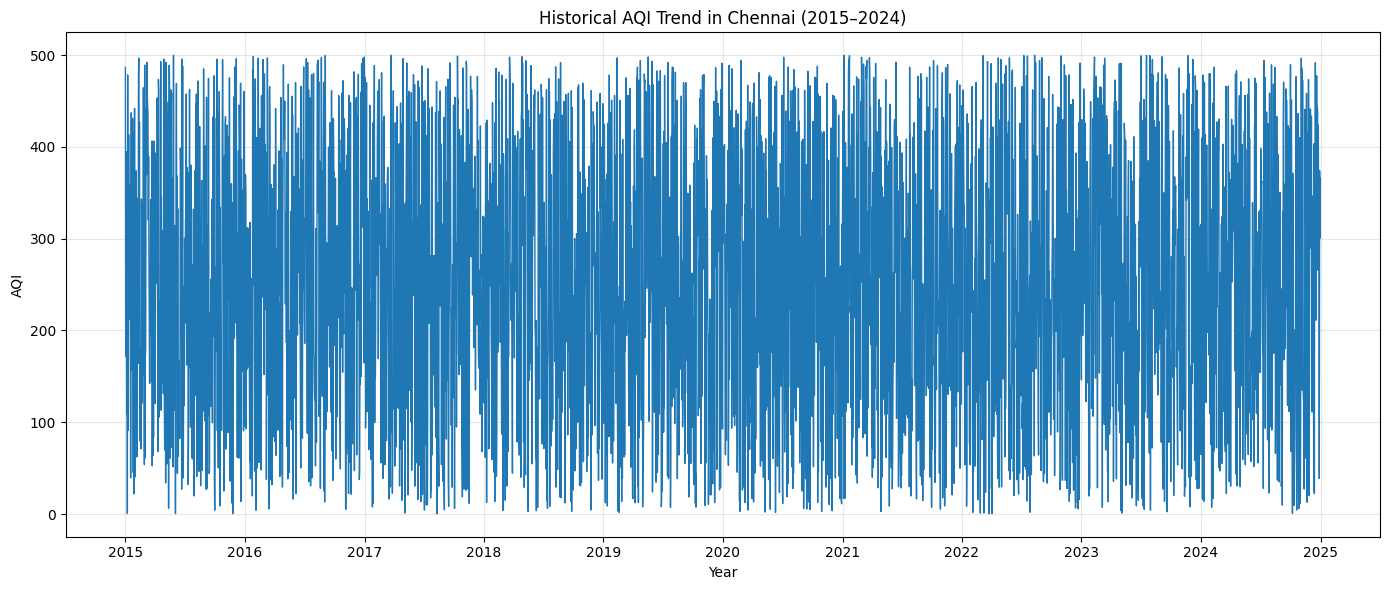

In [5]:
# Plot historical AQI trend for Chennai

plt.figure(figsize=(14, 6))

plt.plot(
    chennai_df["Datetime"],
    chennai_df["AQI"],
    linewidth=1
)

plt.title("Historical AQI Trend in Chennai (2015–2024)")
plt.xlabel("Year")
plt.ylabel("AQI")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Calculate yearly average AQI

chennai_df["Year"] = chennai_df["Datetime"].dt.year

yearly_aqi = (
    chennai_df
    .groupby("Year")["AQI"]
    .mean()
    .reset_index()
)

print("Yearly Average AQI:")
display(yearly_aqi)

Yearly Average AQI:


,Year,AQI
0,2015,247.792603
1,2016,257.591257
2,2017,259.685205
3,2018,247.322466
4,2019,246.097534
5,2020,239.742623
6,2021,254.899726
7,2022,241.335342
8,2023,251.515616
9,2024,257.395082


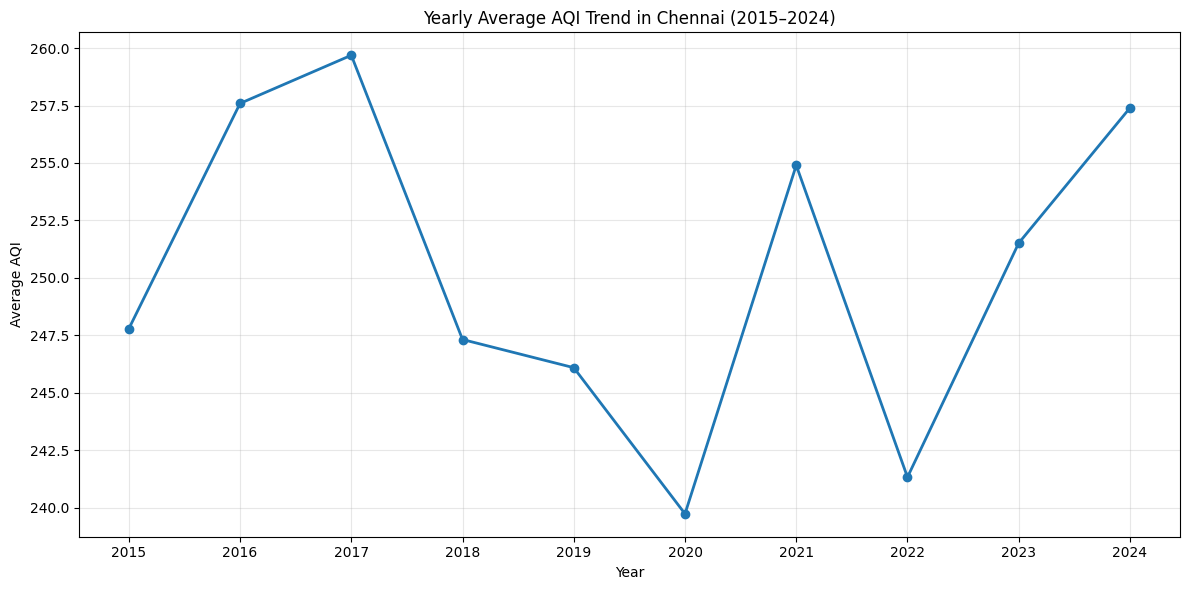

In [7]:
# Plot yearly average AQI trend

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_aqi["Year"],
    yearly_aqi["AQI"],
    marker="o",
    linewidth=2
)

plt.title("Yearly Average AQI Trend in Chennai (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.xticks(yearly_aqi["Year"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Analyze correlations between pollutants and AQI

pollutant_columns = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene",
    "AQI"
]

correlation_matrix = chennai_df[pollutant_columns].corr()

# Display correlation of each pollutant with AQI
aqi_correlation = (
    correlation_matrix["AQI"]
    .drop("AQI")
    .sort_values(ascending=False)
)

print("Correlation of pollutants with AQI:")
display(aqi_correlation)

Correlation of pollutants with AQI:


,AQI
PM10,0.030178
NO2,0.020827
Xylene,0.017971
CO,0.014507
SO2,0.012844
NH3,0.003586
Toluene,0.002621
PM2.5,-0.005168
Benzene,-0.006311
NO,-0.009801


In [9]:
# Create time-series features for AQI forecasting

# Previous-day AQI
chennai_df["AQI_Lag_1"] = chennai_df["AQI"].shift(1)

# AQI from 7 days ago
chennai_df["AQI_Lag_7"] = chennai_df["AQI"].shift(7)

# AQI from 30 days ago
chennai_df["AQI_Lag_30"] = chennai_df["AQI"].shift(30)

# 7-day rolling average using previous observations
chennai_df["AQI_Rolling_7"] = (
    chennai_df["AQI"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

# 30-day rolling average using previous observations
chennai_df["AQI_Rolling_30"] = (
    chennai_df["AQI"]
    .shift(1)
    .rolling(window=30)
    .mean()
)

# Calendar features
chennai_df["Month"] = chennai_df["Datetime"].dt.month
chennai_df["Day"] = chennai_df["Datetime"].dt.day
chennai_df["DayOfWeek"] = chennai_df["Datetime"].dt.dayofweek

# Remove rows created by lag/rolling calculations
model_df = chennai_df.dropna().copy()

print("Original Chennai records:", len(chennai_df))
print("Records available for modeling:", len(model_df))

print("\nNew prediction features:")
print([
    "AQI_Lag_1",
    "AQI_Lag_7",
    "AQI_Lag_30",
    "AQI_Rolling_7",
    "AQI_Rolling_30",
    "Month",
    "Day",
    "DayOfWeek"
])

print("\nModeling dataset:")
display(model_df.head())

Original Chennai records: 3653
Records available for modeling: 3623

New prediction features:
['AQI_Lag_1', 'AQI_Lag_7', 'AQI_Lag_30', 'AQI_Rolling_7', 'AQI_Rolling_30', 'Month', 'Day', 'DayOfWeek']

Modeling dataset:


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,AQI_Bucket,Year,AQI_Lag_1,AQI_Lag_7,AQI_Lag_30,AQI_Rolling_7,AQI_Rolling_30,Month,Day,DayOfWeek
30,Chennai,2015-01-31,18.5,301.8,131.1,135.2,90.1,49.8,0.11,97.6,...,Satisfactory,2015,150.2,251.4,486.5,219.757143,263.910000,1,31,5
31,Chennai,2015-02-01,280.3,116.3,183.7,7.2,209.2,37.6,3.96,47.2,...,Severe,2015,40.6,45.3,171.7,189.642857,249.046667,2,1,6
32,Chennai,2015-02-02,415.4,322.5,7.9,122.1,242.8,23.3,8.88,17.4,...,Very Poor,2015,102.3,415.6,394.8,197.785714,246.733333,2,2,0
33,Chennai,2015-02-03,391.0,113.5,71.8,54.5,203.3,7.7,5.41,32.7,...,Severe,2015,215.4,22.0,286.1,169.185714,240.753333,2,3,1
34,Chennai,2015-02-04,212.3,11.5,189.4,1.7,208.4,8.1,6.44,12.1,...,Severe,2015,373.9,211.9,108.8,219.457143,243.680000,2,4,2


In [2]:
# ============================================================
# PREPARE DATA AND CREATE TIME-BASED TRAIN/VALIDATION/TEST SET
# ============================================================

import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("city_day.csv")

# Convert date column
df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")

# Select Chennai
chennai = df[df["City"].str.lower() == "chennai"].copy()

# Sort by date
chennai = chennai.sort_values("Datetime").reset_index(drop=True)

print("Original Chennai records:", len(chennai))

# Keep only rows where AQI is available
chennai = chennai.dropna(subset=["AQI"]).copy()

# Create modeling features
chennai["AQI_Lag_1"] = chennai["AQI"].shift(1)
chennai["AQI_Lag_7"] = chennai["AQI"].shift(7)
chennai["AQI_Lag_30"] = chennai["AQI"].shift(30)

chennai["AQI_Rolling_7"] = (
    chennai["AQI"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

chennai["AQI_Rolling_30"] = (
    chennai["AQI"]
    .shift(1)
    .rolling(window=30)
    .mean()
)

# Calendar features
chennai["Month"] = chennai["Datetime"].dt.month
chennai["Day"] = chennai["Datetime"].dt.day
chennai["DayOfWeek"] = chennai["Datetime"].dt.dayofweek

# Remove rows created by lag/rolling calculations
modeling_data = chennai.dropna(
    subset=[
        "AQI_Lag_1",
        "AQI_Lag_7",
        "AQI_Lag_30",
        "AQI_Rolling_7",
        "AQI_Rolling_30"
    ]
).copy()

print("Records available for modeling:", len(modeling_data))

print("\nNew prediction features:")
print([
    "AQI_Lag_1",
    "AQI_Lag_7",
    "AQI_Lag_30",
    "AQI_Rolling_7",
    "AQI_Rolling_30",
    "Month",
    "Day",
    "DayOfWeek"
])

# ============================================================
# TIME-BASED SPLIT
# ============================================================

n = len(modeling_data)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_data = modeling_data.iloc[:train_end].copy()
validation_data = modeling_data.iloc[train_end:validation_end].copy()
test_data = modeling_data.iloc[validation_end:].copy()

print("\n" + "=" * 60)
print("TIME-BASED DATA SPLIT")
print("=" * 60)

print("\nTraining Data:")
print("Start:", train_data["Datetime"].min().date())
print("End:", train_data["Datetime"].max().date())
print("Records:", len(train_data))

print("\nValidation Data:")
print("Start:", validation_data["Datetime"].min().date())
print("End:", validation_data["Datetime"].max().date())
print("Records:", len(validation_data))

print("\nTesting Data:")
print("Start:", test_data["Datetime"].min().date())
print("End:", test_data["Datetime"].max().date())
print("Records:", len(test_data))

Original Chennai records: 3653
Records available for modeling: 3623

New prediction features:
['AQI_Lag_1', 'AQI_Lag_7', 'AQI_Lag_30', 'AQI_Rolling_7', 'AQI_Rolling_30', 'Month', 'Day', 'DayOfWeek']

TIME-BASED DATA SPLIT

Training Data:
Start: 2015-01-31
End: 2022-01-09
Records: 2536

Validation Data:
Start: 2022-01-10
End: 2023-07-06
Records: 543

Testing Data:
Start: 2023-07-07
End: 2024-12-31
Records: 544


In [3]:
# ============================================================
# PREPARE FEATURES (X) AND TARGET (y)
# ============================================================

prediction_features = [
    "AQI_Lag_1",
    "AQI_Lag_7",
    "AQI_Lag_30",
    "AQI_Rolling_7",
    "AQI_Rolling_30",
    "Month",
    "Day",
    "DayOfWeek"
]

target = "AQI"

# Training data
X_train = train_data[prediction_features]
y_train = train_data[target]

# Validation data
X_val = validation_data[prediction_features]
y_val = validation_data[target]

# Testing data
X_test = test_data[prediction_features]
y_test = test_data[target]

print("=" * 60)
print("FEATURES AND TARGET PREPARED")
print("=" * 60)

print("\nPrediction features:")
print(prediction_features)

print("\nTarget variable:")
print(target)

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

FEATURES AND TARGET PREPARED

Prediction features:
['AQI_Lag_1', 'AQI_Lag_7', 'AQI_Lag_30', 'AQI_Rolling_7', 'AQI_Rolling_30', 'Month', 'Day', 'DayOfWeek']

Target variable:
AQI

Shapes:
X_train: (2536, 8)
y_train: (2536,)
X_val: (543, 8)
y_val: (543,)
X_test: (544, 8)
y_test: (544,)


Train Linear Regression

In [4]:
# ============================================================
# LINEAR REGRESSION MODEL
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model using training data
linear_model.fit(X_train, y_train)

# Predict AQI on validation data
linear_val_predictions = linear_model.predict(X_val)

# Calculate validation metrics
linear_mae = mean_absolute_error(
    y_val,
    linear_val_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        linear_val_predictions
    )
)

linear_r2 = r2_score(
    y_val,
    linear_val_predictions
)

# Display results
print("=" * 60)
print("LINEAR REGRESSION - VALIDATION RESULTS")
print("=" * 60)

print(f"\nMAE      : {linear_mae:.2f}")
print(f"RMSE     : {linear_rmse:.2f}")
print(f"R² Score : {linear_r2:.4f}")

LINEAR REGRESSION - VALIDATION RESULTS

MAE      : 123.06
RMSE     : 144.08
R² Score : -0.0019


In [5]:
# ============================================================
# RANDOM FOREST REGRESSION MODEL
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Random Forest model
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(
    X_train,
    y_train
)

# Predict AQI on validation data
rf_val_predictions = random_forest_model.predict(
    X_val
)

# Calculate validation metrics
rf_mae = mean_absolute_error(
    y_val,
    rf_val_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_val_predictions
    )
)

rf_r2 = r2_score(
    y_val,
    rf_val_predictions
)

# Display results
print("=" * 60)
print("RANDOM FOREST - VALIDATION RESULTS")
print("=" * 60)

print(f"\nMAE      : {rf_mae:.2f}")
print(f"RMSE     : {rf_rmse:.2f}")
print(f"R² Score : {rf_r2:.4f}")

RANDOM FOREST - VALIDATION RESULTS

MAE      : 123.42
RMSE     : 144.32
R² Score : -0.0054


In [6]:
# ============================================================
# GRADIENT BOOSTING REGRESSION MODEL
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Gradient Boosting model
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model
gradient_boosting_model.fit(
    X_train,
    y_train
)

# Predict AQI on validation data
gb_val_predictions = gradient_boosting_model.predict(
    X_val
)

# Calculate validation metrics
gb_mae = mean_absolute_error(
    y_val,
    gb_val_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        gb_val_predictions
    )
)

gb_r2 = r2_score(
    y_val,
    gb_val_predictions
)

# Display results
print("=" * 60)
print("GRADIENT BOOSTING - VALIDATION RESULTS")
print("=" * 60)

print(f"\nMAE      : {gb_mae:.2f}")
print(f"RMSE     : {gb_rmse:.2f}")
print(f"R² Score : {gb_r2:.4f}")

GRADIENT BOOSTING - VALIDATION RESULTS

MAE      : 124.71
RMSE     : 146.16
R² Score : -0.0311


In [7]:
# ============================================================
# IMPROVED TIME-SERIES FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np

# Reload the original dataset
df = pd.read_csv("city_day.csv")

# Convert date
df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

# Select Chennai
chennai = df[
    df["City"].str.lower() == "chennai"
].copy()

# Sort chronologically
chennai = chennai.sort_values(
    "Datetime"
).reset_index(drop=True)

# Keep rows where AQI is available
chennai = chennai.dropna(
    subset=["AQI"]
).copy()

# ============================================================
# LAG FEATURES
# ============================================================

chennai["AQI_Lag_1"] = chennai["AQI"].shift(1)
chennai["AQI_Lag_2"] = chennai["AQI"].shift(2)
chennai["AQI_Lag_3"] = chennai["AQI"].shift(3)
chennai["AQI_Lag_7"] = chennai["AQI"].shift(7)
chennai["AQI_Lag_14"] = chennai["AQI"].shift(14)
chennai["AQI_Lag_21"] = chennai["AQI"].shift(21)
chennai["AQI_Lag_30"] = chennai["AQI"].shift(30)
chennai["AQI_Lag_60"] = chennai["AQI"].shift(60)

# ============================================================
# ROLLING FEATURES
# ============================================================

chennai["AQI_Rolling_Mean_7"] = (
    chennai["AQI"]
    .shift(1)
    .rolling(7)
    .mean()
)

chennai["AQI_Rolling_Mean_14"] = (
    chennai["AQI"]
    .shift(1)
    .rolling(14)
    .mean()
)

chennai["AQI_Rolling_Mean_30"] = (
    chennai["AQI"]
    .shift(1)
    .rolling(30)
    .mean()
)

chennai["AQI_Rolling_Median_7"] = (
    chennai["AQI"]
    .shift(1)
    .rolling(7)
    .median()
)

chennai["AQI_Rolling_Min_7"] = (
    chennai["AQI"]
    .shift(1)
    .rolling(7)
    .min()
)

chennai["AQI_Rolling_Max_7"] = (
    chennai["AQI"]
    .shift(1)
    .rolling(7)
    .max()
)

chennai["AQI_Rolling_Std_7"] = (
    chennai["AQI"]
    .shift(1)
    .rolling(7)
    .std()
)

chennai["AQI_Rolling_Std_30"] = (
    chennai["AQI"]
    .shift(1)
    .rolling(30)
    .std()
)

# ============================================================
# EXPONENTIALLY WEIGHTED FEATURES
# ============================================================

chennai["AQI_EWM_7"] = (
    chennai["AQI"]
    .shift(1)
    .ewm(span=7, adjust=False)
    .mean()
)

chennai["AQI_EWM_30"] = (
    chennai["AQI"]
    .shift(1)
    .ewm(span=30, adjust=False)
    .mean()
)

# ============================================================
# TREND FEATURES
# ============================================================

chennai["AQI_Trend_7"] = (
    chennai["AQI_Lag_1"]
    - chennai["AQI_Lag_7"]
)

chennai["AQI_Trend_30"] = (
    chennai["AQI_Lag_1"]
    - chennai["AQI_Lag_30"]
)

# ============================================================
# CALENDAR FEATURES
# ============================================================

chennai["Month"] = chennai["Datetime"].dt.month
chennai["Day"] = chennai["Datetime"].dt.day
chennai["DayOfWeek"] = chennai["Datetime"].dt.dayofweek
chennai["Quarter"] = chennai["Datetime"].dt.quarter
chennai["DayOfYear"] = chennai["Datetime"].dt.dayofyear

# Weekend indicator
chennai["IsWeekend"] = (
    chennai["DayOfWeek"] >= 5
).astype(int)

# ============================================================
# CYCLICAL SEASONAL FEATURES
# ============================================================

chennai["Month_Sin"] = np.sin(
    2 * np.pi * chennai["Month"] / 12
)

chennai["Month_Cos"] = np.cos(
    2 * np.pi * chennai["Month"] / 12
)

chennai["DayOfYear_Sin"] = np.sin(
    2 * np.pi * chennai["DayOfYear"] / 365.25
)

chennai["DayOfYear_Cos"] = np.cos(
    2 * np.pi * chennai["DayOfYear"] / 365.25
)

# ============================================================
# REMOVE ROWS WITH MISSING FEATURE VALUES
# ============================================================

modeling_data = chennai.dropna().copy()

print("=" * 60)
print("IMPROVED FEATURE ENGINEERING COMPLETED")
print("=" * 60)

print("\nOriginal Chennai records:", len(chennai))

print(
    "Records available for modeling:",
    len(modeling_data)
)

print(
    "\nNumber of features:",
    len(modeling_data.columns)
)

print("\nNew feature list:")

feature_columns = [
    col for col in modeling_data.columns
    if col not in [
        "City",
        "Datetime",
        "AQI",
        "AQI_Bucket"
    ]
]

print(feature_columns)

print(
    "\nModeling dataset shape:",
    modeling_data.shape
)

IMPROVED FEATURE ENGINEERING COMPLETED

Original Chennai records: 3653
Records available for modeling: 3593

Number of features: 46

New feature list:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI_Lag_1', 'AQI_Lag_2', 'AQI_Lag_3', 'AQI_Lag_7', 'AQI_Lag_14', 'AQI_Lag_21', 'AQI_Lag_30', 'AQI_Lag_60', 'AQI_Rolling_Mean_7', 'AQI_Rolling_Mean_14', 'AQI_Rolling_Mean_30', 'AQI_Rolling_Median_7', 'AQI_Rolling_Min_7', 'AQI_Rolling_Max_7', 'AQI_Rolling_Std_7', 'AQI_Rolling_Std_30', 'AQI_EWM_7', 'AQI_EWM_30', 'AQI_Trend_7', 'AQI_Trend_30', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'DayOfYear', 'IsWeekend', 'Month_Sin', 'Month_Cos', 'DayOfYear_Sin', 'DayOfYear_Cos']

Modeling dataset shape: (3593, 46)


In [8]:
# ============================================================
# IMPROVED TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Prediction features
prediction_features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene",
    "AQI_Lag_1",
    "AQI_Lag_2",
    "AQI_Lag_3",
    "AQI_Lag_7",
    "AQI_Lag_14",
    "AQI_Lag_21",
    "AQI_Lag_30",
    "AQI_Lag_60",
    "AQI_Rolling_Mean_7",
    "AQI_Rolling_Mean_14",
    "AQI_Rolling_Mean_30",
    "AQI_Rolling_Median_7",
    "AQI_Rolling_Min_7",
    "AQI_Rolling_Max_7",
    "AQI_Rolling_Std_7",
    "AQI_Rolling_Std_30",
    "AQI_EWM_7",
    "AQI_EWM_30",
    "AQI_Trend_7",
    "AQI_Trend_30",
    "Month",
    "Day",
    "DayOfWeek",
    "Quarter",
    "DayOfYear",
    "IsWeekend",
    "Month_Sin",
    "Month_Cos",
    "DayOfYear_Sin",
    "DayOfYear_Cos"
]

target = "AQI"

# ------------------------------------------------------------
# Create X and y
# ------------------------------------------------------------

X = modeling_data[prediction_features]
y = modeling_data[target]

# ------------------------------------------------------------
# Time-based split
# 70% Train
# 15% Validation
# 15% Test
# ------------------------------------------------------------

n = len(modeling_data)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

X_val = X.iloc[train_end:validation_end].copy()
y_val = y.iloc[train_end:validation_end].copy()

X_test = X.iloc[validation_end:].copy()
y_test = y.iloc[validation_end:].copy()

# ------------------------------------------------------------
# Display split information
# ------------------------------------------------------------

print("=" * 60)
print("IMPROVED TIME-BASED DATA SPLIT")
print("=" * 60)

print("\nTraining Data:")
print("Start:", modeling_data["Datetime"].iloc[:train_end].min().date())
print("End:", modeling_data["Datetime"].iloc[:train_end].max().date())
print("Records:", len(X_train))

print("\nValidation Data:")
print("Start:", modeling_data["Datetime"].iloc[train_end:validation_end].min().date())
print("End:", modeling_data["Datetime"].iloc[train_end:validation_end].max().date())
print("Records:", len(X_val))

print("\nTesting Data:")
print("Start:", modeling_data["Datetime"].iloc[validation_end:].min().date())
print("End:", modeling_data["Datetime"].iloc[validation_end:].max().date())
print("Records:", len(X_test))

print("\nNumber of prediction features:", len(prediction_features))

print("\nFeature matrix shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

IMPROVED TIME-BASED DATA SPLIT

Training Data:
Start: 2015-03-02
End: 2022-01-18
Records: 2515

Validation Data:
Start: 2022-01-19
End: 2023-07-11
Records: 539

Testing Data:
Start: 2023-07-12
End: 2024-12-31
Records: 539

Number of prediction features: 42

Feature matrix shapes:
X_train: (2515, 42)
X_val: (539, 42)
X_test: (539, 42)


In [9]:
# ============================================================
# IMPROVED LINEAR REGRESSION MODEL
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create scaler
linear_scaler = StandardScaler()

# Scale training and validation features
X_train_scaled = linear_scaler.fit_transform(X_train)
X_val_scaled = linear_scaler.transform(X_val)

# Create Linear Regression model
linear_model = LinearRegression()

# Train model
linear_model.fit(
    X_train_scaled,
    y_train
)

# Predict validation AQI
linear_val_predictions = linear_model.predict(
    X_val_scaled
)

# Calculate metrics
linear_mae = mean_absolute_error(
    y_val,
    linear_val_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        linear_val_predictions
    )
)

linear_r2 = r2_score(
    y_val,
    linear_val_predictions
)

# Display results
print("=" * 60)
print("IMPROVED LINEAR REGRESSION - VALIDATION RESULTS")
print("=" * 60)

print(f"\nMAE      : {linear_mae:.2f}")
print(f"RMSE     : {linear_rmse:.2f}")
print(f"R² Score : {linear_r2:.4f}")

IMPROVED LINEAR REGRESSION - VALIDATION RESULTS

MAE      : 124.56
RMSE     : 146.10
R² Score : -0.0238


In [10]:
# ============================================================
# IMPROVED RANDOM FOREST REGRESSION
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create improved Random Forest model
random_forest_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(
    X_train,
    y_train
)

# Predict validation AQI
rf_val_predictions = random_forest_model.predict(
    X_val
)

# Calculate metrics
rf_mae = mean_absolute_error(
    y_val,
    rf_val_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_val_predictions
    )
)

rf_r2 = r2_score(
    y_val,
    rf_val_predictions
)

# Display results
print("=" * 60)
print("IMPROVED RANDOM FOREST - VALIDATION RESULTS")
print("=" * 60)

print(f"\nMAE      : {rf_mae:.2f}")
print(f"RMSE     : {rf_rmse:.2f}")
print(f"R² Score : {rf_r2:.4f}")

IMPROVED RANDOM FOREST - VALIDATION RESULTS

MAE      : 124.41
RMSE     : 145.68
R² Score : -0.0180


In [11]:
# ============================================================
# IMPROVED GRADIENT BOOSTING REGRESSION
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Gradient Boosting model
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

# Train the model
gradient_boosting_model.fit(
    X_train,
    y_train
)

# Predict validation AQI
gb_val_predictions = gradient_boosting_model.predict(
    X_val
)

# Calculate metrics
gb_mae = mean_absolute_error(
    y_val,
    gb_val_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        gb_val_predictions
    )
)

gb_r2 = r2_score(
    y_val,
    gb_val_predictions
)

# Display results
print("=" * 60)
print("IMPROVED GRADIENT BOOSTING - VALIDATION RESULTS")
print("=" * 60)

print(f"\nMAE      : {gb_mae:.2f}")
print(f"RMSE     : {gb_rmse:.2f}")
print(f"R² Score : {gb_r2:.4f}")

IMPROVED GRADIENT BOOSTING - VALIDATION RESULTS

MAE      : 127.53
RMSE     : 149.79
R² Score : -0.0762


In [12]:
# ============================================================
# FORECASTING BASELINE COMPARISON
# ============================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 60)
print("BASELINE FORECASTING COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# Baseline 1: Previous day's AQI
# ------------------------------------------------------------

naive_predictions = test_data["AQI_Lag_1"].values

naive_mae = mean_absolute_error(
    y_test,
    naive_predictions
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_predictions
    )
)

naive_r2 = r2_score(
    y_test,
    naive_predictions
)

print("\n1. NAIVE FORECAST (Previous Day AQI)")
print(f"MAE      : {naive_mae:.2f}")
print(f"RMSE     : {naive_rmse:.2f}")
print(f"R² Score : {naive_r2:.4f}")


# ------------------------------------------------------------
# Baseline 2: 7-day lag
# ------------------------------------------------------------

lag7_predictions = test_data["AQI_Lag_7"].values

lag7_mae = mean_absolute_error(
    y_test,
    lag7_predictions
)

lag7_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lag7_predictions
    )
)

lag7_r2 = r2_score(
    y_test,
    lag7_predictions
)

print("\n2. 7-DAY LAG FORECAST")
print(f"MAE      : {lag7_mae:.2f}")
print(f"RMSE     : {lag7_rmse:.2f}")
print(f"R² Score : {lag7_r2:.4f}")


# ------------------------------------------------------------
# Baseline 3: 7-day rolling mean
# ------------------------------------------------------------

rolling_predictions = test_data["AQI_Rolling_Mean_7"].values

rolling_mae = mean_absolute_error(
    y_test,
    rolling_predictions
)

rolling_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rolling_predictions
    )
)

rolling_r2 = r2_score(
    y_test,
    rolling_predictions
)

print("\n3. 7-DAY ROLLING MEAN")
print(f"MAE      : {rolling_mae:.2f}")
print(f"RMSE     : {rolling_rmse:.2f}")
print(f"R² Score : {rolling_r2:.4f}")


# ------------------------------------------------------------
# Create baseline comparison table
# ------------------------------------------------------------

baseline_results = pd.DataFrame({
    "Model": [
        "Naive - Previous Day",
        "7-Day Lag",
        "7-Day Rolling Mean"
    ],
    "MAE": [
        naive_mae,
        lag7_mae,
        rolling_mae
    ],
    "RMSE": [
        naive_rmse,
        lag7_rmse,
        rolling_rmse
    ],
    "R2 Score": [
        naive_r2,
        lag7_r2,
        rolling_r2
    ]
})

print("\n" + "=" * 60)
print("BASELINE COMPARISON TABLE")
print("=" * 60)

display(
    baseline_results.round(3)
)

BASELINE FORECASTING COMPARISON


ValueError: Found input variables with inconsistent numbers of samples: [539, 544]

In [13]:
# ============================================================
# FIX TEST DATA + BASELINE FORECAST COMPARISON
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# Recreate the test split from the CURRENT modeling_data
# ------------------------------------------------------------

n = len(modeling_data)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

test_data = modeling_data.iloc[validation_end:].copy()

# Actual AQI values
y_test = test_data["AQI"].copy()

print("=" * 60)
print("TEST DATA CHECK")
print("=" * 60)

print("\nTest records:", len(test_data))
print("AQI records:", len(y_test))

print(
    "\nTest period:",
    test_data["Datetime"].min().date(),
    "to",
    test_data["Datetime"].max().date()
)

# ------------------------------------------------------------
# BASELINE 1
# Previous day's AQI
# ------------------------------------------------------------

naive_predictions = test_data["AQI_Lag_1"]

naive_mae = mean_absolute_error(
    y_test,
    naive_predictions
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_predictions
    )
)

naive_r2 = r2_score(
    y_test,
    naive_predictions
)

# ------------------------------------------------------------
# BASELINE 2
# AQI from 7 days ago
# ------------------------------------------------------------

lag7_predictions = test_data["AQI_Lag_7"]

lag7_mae = mean_absolute_error(
    y_test,
    lag7_predictions
)

lag7_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lag7_predictions
    )
)

lag7_r2 = r2_score(
    y_test,
    lag7_predictions
)

# ------------------------------------------------------------
# BASELINE 3
# 7-day rolling average
# ------------------------------------------------------------

rolling_predictions = test_data["AQI_Rolling_Mean_7"]

rolling_mae = mean_absolute_error(
    y_test,
    rolling_predictions
)

rolling_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rolling_predictions
    )
)

rolling_r2 = r2_score(
    y_test,
    rolling_predictions
)

# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

baseline_results = pd.DataFrame({

    "Model": [
        "Naive - Previous Day",
        "7-Day Lag",
        "7-Day Rolling Mean"
    ],

    "MAE": [
        naive_mae,
        lag7_mae,
        rolling_mae
    ],

    "RMSE": [
        naive_rmse,
        lag7_rmse,
        rolling_rmse
    ],

    "R2 Score": [
        naive_r2,
        lag7_r2,
        rolling_r2
    ]
})

print("\n" + "=" * 60)
print("BASELINE FORECASTING RESULTS")
print("=" * 60)

display(
    baseline_results.round(3)
)

TEST DATA CHECK

Test records: 539
AQI records: 539

Test period: 2023-07-12 to 2024-12-31

BASELINE FORECASTING RESULTS


,Model,MAE,RMSE,R2 Score
0,Naive - Previous Day,165.444,205.126,-0.984
1,7-Day Lag,180.984,219.732,-1.276
2,7-Day Rolling Mean,135.435,158.559,-0.185


In [14]:
# ============================================================
# AQI DISTRIBUTION DIAGNOSTIC
# ============================================================

print("=" * 60)
print("AQI DISTRIBUTION ACROSS TIME PERIODS")
print("=" * 60)

# Training AQI statistics
train_aqi = train_data["AQI"]

# Validation AQI statistics
validation_aqi = validation_data["AQI"]

# Current test AQI statistics
test_aqi = test_data["AQI"]

print("\nTRAINING PERIOD")
print("-" * 40)
print("Mean AQI   :", round(train_aqi.mean(), 2))
print("Median AQI :", round(train_aqi.median(), 2))
print("Std AQI    :", round(train_aqi.std(), 2))
print("Minimum    :", round(train_aqi.min(), 2))
print("Maximum    :", round(train_aqi.max(), 2))

print("\nVALIDATION PERIOD")
print("-" * 40)
print("Mean AQI   :", round(validation_aqi.mean(), 2))
print("Median AQI :", round(validation_aqi.median(), 2))
print("Std AQI    :", round(validation_aqi.std(), 2))
print("Minimum    :", round(validation_aqi.min(), 2))
print("Maximum    :", round(validation_aqi.max(), 2))

print("\nTEST PERIOD")
print("-" * 40)
print("Mean AQI   :", round(test_aqi.mean(), 2))
print("Median AQI :", round(test_aqi.median(), 2))
print("Std AQI    :", round(test_aqi.std(), 2))
print("Minimum    :", round(test_aqi.min(), 2))
print("Maximum    :", round(test_aqi.max(), 2))


# ============================================================
# VISUAL COMPARISON
# ============================================================

period_means = [
    train_aqi.mean(),
    validation_aqi.mean(),
    test_aqi.mean()
]

period_names = [
    "Training",
    "Validation",
    "Testing"
]

plt.figure(figsize=(9, 6))

plt.bar(
    period_names,
    period_means
)

plt.title("Average AQI Across Modeling Periods")
plt.xlabel("Dataset Period")
plt.ylabel("Average AQI")

plt.tight_layout()
plt.show()

AQI DISTRIBUTION ACROSS TIME PERIODS

TRAINING PERIOD
----------------------------------------
Mean AQI   : 250.5
Median AQI : 249.85
Std AQI    : 144.8
Minimum    : 0.3
Maximum    : 499.8

VALIDATION PERIOD
----------------------------------------
Mean AQI   : 244.15
Median AQI : 238.1
Std AQI    : 144.07
Minimum    : 0.4
Maximum    : 499.8

TEST PERIOD
----------------------------------------
Mean AQI   : 254.97
Median AQI : 252.1
Std AQI    : 145.78
Minimum    : 0.8
Maximum    : 499.7


NameError: name 'plt' is not defined

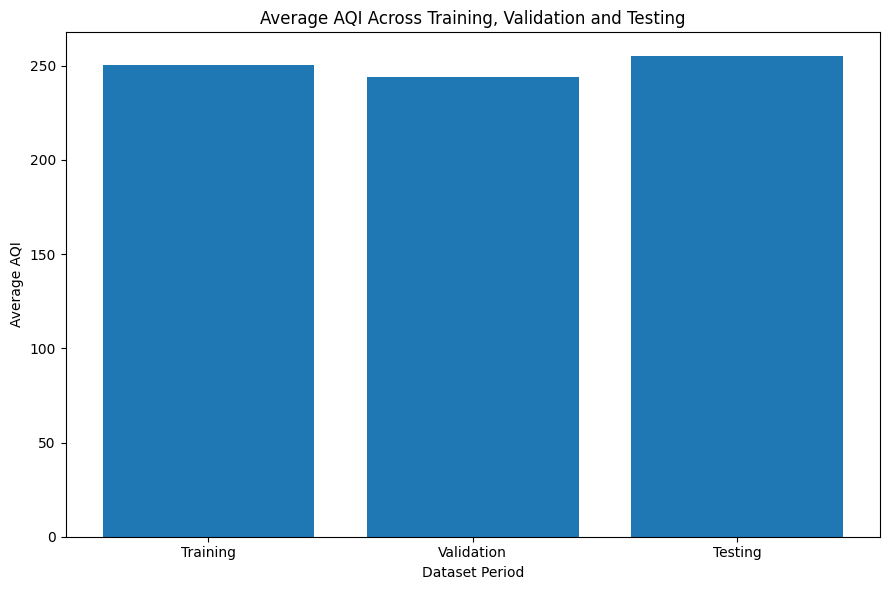

In [15]:
# ============================================================
# AQI PERIOD COMPARISON VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

period_names = [
    "Training",
    "Validation",
    "Testing"
]

period_means = [
    train_data["AQI"].mean(),
    validation_data["AQI"].mean(),
    test_data["AQI"].mean()
]

plt.figure(figsize=(9, 6))

plt.bar(
    period_names,
    period_means
)

plt.title("Average AQI Across Training, Validation and Testing")
plt.xlabel("Dataset Period")
plt.ylabel("Average AQI")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# PROPER FUTURE AQI FORECASTING FEATURES
# ============================================================
# Important:
# We use only information available BEFORE the AQI being predicted.
# This prevents same-day pollutant target leakage.
# ============================================================

import pandas as pd
import numpy as np

# Reload original dataset
df = pd.read_csv("city_day.csv")

# Convert date
df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

# Select Chennai
chennai_forecast = df[
    df["City"].str.lower() == "chennai"
].copy()

# Sort by date
chennai_forecast = chennai_forecast.sort_values(
    "Datetime"
).reset_index(drop=True)

# Keep rows with AQI
chennai_forecast = chennai_forecast.dropna(
    subset=["AQI"]
).copy()

# ============================================================
# HISTORICAL AQI FEATURES
# ============================================================

chennai_forecast["AQI_Lag_1"] = (
    chennai_forecast["AQI"].shift(1)
)

chennai_forecast["AQI_Lag_2"] = (
    chennai_forecast["AQI"].shift(2)
)

chennai_forecast["AQI_Lag_3"] = (
    chennai_forecast["AQI"].shift(3)
)

chennai_forecast["AQI_Lag_7"] = (
    chennai_forecast["AQI"].shift(7)
)

chennai_forecast["AQI_Lag_14"] = (
    chennai_forecast["AQI"].shift(14)
)

chennai_forecast["AQI_Lag_30"] = (
    chennai_forecast["AQI"].shift(30)
)

# ============================================================
# AQI ROLLING FEATURES
# ============================================================

chennai_forecast["AQI_Rolling_Mean_7"] = (
    chennai_forecast["AQI"]
    .shift(1)
    .rolling(7)
    .mean()
)

chennai_forecast["AQI_Rolling_Mean_14"] = (
    chennai_forecast["AQI"]
    .shift(1)
    .rolling(14)
    .mean()
)

chennai_forecast["AQI_Rolling_Mean_30"] = (
    chennai_forecast["AQI"]
    .shift(1)
    .rolling(30)
    .mean()
)

chennai_forecast["AQI_Rolling_Std_7"] = (
    chennai_forecast["AQI"]
    .shift(1)
    .rolling(7)
    .std()
)

# ============================================================
# POLLUTANT LAG FEATURES
# ============================================================

pollutants = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene"
]

for pollutant in pollutants:

    # Previous day's pollutant value
    chennai_forecast[
        pollutant + "_Lag_1"
    ] = chennai_forecast[pollutant].shift(1)

    # Pollutant value from 7 days ago
    chennai_forecast[
        pollutant + "_Lag_7"
    ] = chennai_forecast[pollutant].shift(7)

# ============================================================
# CALENDAR FEATURES
# ============================================================

chennai_forecast["Month"] = (
    chennai_forecast["Datetime"].dt.month
)

chennai_forecast["Day"] = (
    chennai_forecast["Datetime"].dt.day
)

chennai_forecast["DayOfWeek"] = (
    chennai_forecast["Datetime"].dt.dayofweek
)

chennai_forecast["Quarter"] = (
    chennai_forecast["Datetime"].dt.quarter
)

chennai_forecast["DayOfYear"] = (
    chennai_forecast["Datetime"].dt.dayofyear
)

chennai_forecast["IsWeekend"] = (
    chennai_forecast["DayOfWeek"] >= 5
).astype(int)

# ============================================================
# CYCLICAL FEATURES
# ============================================================

chennai_forecast["Month_Sin"] = np.sin(
    2 * np.pi * chennai_forecast["Month"] / 12
)

chennai_forecast["Month_Cos"] = np.cos(
    2 * np.pi * chennai_forecast["Month"] / 12
)

chennai_forecast["DayOfYear_Sin"] = np.sin(
    2 * np.pi *
    chennai_forecast["DayOfYear"] / 365.25
)

chennai_forecast["DayOfYear_Cos"] = np.cos(
    2 * np.pi *
    chennai_forecast["DayOfYear"] / 365.25
)

# ============================================================
# CREATE FINAL FORECASTING DATASET
# ============================================================

forecast_modeling_data = chennai_forecast.dropna().copy()

# ============================================================
# SELECT ONLY VALID PREDICTION FEATURES
# ============================================================

forecast_features = [
    col
    for col in forecast_modeling_data.columns
    if col not in [
        "City",
        "Datetime",
        "AQI",
        "AQI_Bucket"
    ]
]

X_forecast = forecast_modeling_data[
    forecast_features
]

y_forecast = forecast_modeling_data[
    "AQI"
]

print("=" * 60)
print("PROPER AQI FORECASTING DATASET")
print("=" * 60)

print(
    "\nOriginal Chennai records:",
    len(chennai_forecast)
)

print(
    "Records available for forecasting:",
    len(forecast_modeling_data)
)

print(
    "\nNumber of prediction features:",
    len(forecast_features)
)

print("\nTarget variable: AQI")

print("\nFirst 10 forecasting features:")
print(forecast_features[:10])

print("\nLast 10 forecasting features:")
print(forecast_features[-10:])

print(
    "\nFinal feature matrix:",
    X_forecast.shape
)

print(
    "Target vector:",
    y_forecast.shape
)

print(
    "\nForecasting period:",
    forecast_modeling_data["Datetime"].min().date(),
    "to",
    forecast_modeling_data["Datetime"].max().date()
)

PROPER AQI FORECASTING DATASET

Original Chennai records: 3653
Records available for forecasting: 3623

Number of prediction features: 56

Target variable: AQI

First 10 forecasting features:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene']

Last 10 forecasting features:
['Month', 'Day', 'DayOfWeek', 'Quarter', 'DayOfYear', 'IsWeekend', 'Month_Sin', 'Month_Cos', 'DayOfYear_Sin', 'DayOfYear_Cos']

Final feature matrix: (3623, 56)
Target vector: (3623,)

Forecasting period: 2015-01-31 to 2024-12-31


In [17]:
# ============================================================
# FINAL TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# 70% Training
# 15% Validation
# 15% Testing

n = len(forecast_modeling_data)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

# Training set
X_train = X_forecast.iloc[:train_end].copy()
y_train = y_forecast.iloc[:train_end].copy()

# Validation set
X_val = X_forecast.iloc[train_end:validation_end].copy()
y_val = y_forecast.iloc[train_end:validation_end].copy()

# Testing set
X_test = X_forecast.iloc[validation_end:].copy()
y_test = y_forecast.iloc[validation_end:].copy()

# Corresponding dates
train_dates = forecast_modeling_data["Datetime"].iloc[:train_end]

validation_dates = forecast_modeling_data[
    "Datetime"
].iloc[train_end:validation_end]

test_dates = forecast_modeling_data[
    "Datetime"
].iloc[validation_end:]

# ============================================================
# DISPLAY SPLIT INFORMATION
# ============================================================

print("=" * 60)
print("FINAL TIME-BASED DATA SPLIT")
print("=" * 60)

print("\nTraining Data:")
print("Start:", train_dates.min().date())
print("End:", train_dates.max().date())
print("Records:", len(X_train))

print("\nValidation Data:")
print("Start:", validation_dates.min().date())
print("End:", validation_dates.max().date())
print("Records:", len(X_val))

print("\nTesting Data:")
print("Start:", test_dates.min().date())
print("End:", test_dates.max().date())
print("Records:", len(X_test))

print("\nPrediction features:", X_train.shape[1])

print("\nFeature matrix shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nTarget shapes:")
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

FINAL TIME-BASED DATA SPLIT

Training Data:
Start: 2015-01-31
End: 2022-01-09
Records: 2536

Validation Data:
Start: 2022-01-10
End: 2023-07-06
Records: 543

Testing Data:
Start: 2023-07-07
End: 2024-12-31
Records: 544

Prediction features: 56

Feature matrix shapes:
X_train: (2536, 56)
X_val: (543, 56)
X_test: (544, 56)

Target shapes:
y_train: (2536,)
y_val: (543,)
y_test: (544,)


In [18]:
# ============================================================
# FINAL LEAKAGE-FREE AQI FORECASTING FEATURES
# ============================================================
# Only information available BEFORE the prediction date
# is used as an input feature.
# ============================================================

import pandas as pd
import numpy as np

# Reload original dataset
df = pd.read_csv("city_day.csv")

# Convert date
df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

# Select Chennai
chennai_final = df[
    df["City"].str.lower() == "chennai"
].copy()

# Sort by date
chennai_final = chennai_final.sort_values(
    "Datetime"
).reset_index(drop=True)

# Keep rows with known AQI
chennai_final = chennai_final.dropna(
    subset=["AQI"]
).copy()

# ============================================================
# HISTORICAL AQI FEATURES
# ============================================================

chennai_final["AQI_Lag_1"] = (
    chennai_final["AQI"].shift(1)
)

chennai_final["AQI_Lag_2"] = (
    chennai_final["AQI"].shift(2)
)

chennai_final["AQI_Lag_3"] = (
    chennai_final["AQI"].shift(3)
)

chennai_final["AQI_Lag_7"] = (
    chennai_final["AQI"].shift(7)
)

chennai_final["AQI_Lag_14"] = (
    chennai_final["AQI"].shift(14)
)

chennai_final["AQI_Lag_30"] = (
    chennai_final["AQI"].shift(30)
)

# ============================================================
# HISTORICAL AQI ROLLING FEATURES
# ============================================================

chennai_final["AQI_Rolling_Mean_7"] = (
    chennai_final["AQI"]
    .shift(1)
    .rolling(7)
    .mean()
)

chennai_final["AQI_Rolling_Mean_14"] = (
    chennai_final["AQI"]
    .shift(1)
    .rolling(14)
    .mean()
)

chennai_final["AQI_Rolling_Mean_30"] = (
    chennai_final["AQI"]
    .shift(1)
    .rolling(30)
    .mean()
)

chennai_final["AQI_Rolling_Std_7"] = (
    chennai_final["AQI"]
    .shift(1)
    .rolling(7)
    .std()
)

# ============================================================
# HISTORICAL POLLUTANT FEATURES
# ============================================================

pollutants = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene"
]

for pollutant in pollutants:

    # Previous day's pollutant
    chennai_final[
        pollutant + "_Lag_1"
    ] = chennai_final[pollutant].shift(1)

    # Pollutant from 7 days ago
    chennai_final[
        pollutant + "_Lag_7"
    ] = chennai_final[pollutant].shift(7)

# ============================================================
# CALENDAR FEATURES
# ============================================================

chennai_final["Month"] = (
    chennai_final["Datetime"].dt.month
)

chennai_final["Day"] = (
    chennai_final["Datetime"].dt.day
)

chennai_final["DayOfWeek"] = (
    chennai_final["Datetime"].dt.dayofweek
)

chennai_final["Quarter"] = (
    chennai_final["Datetime"].dt.quarter
)

chennai_final["DayOfYear"] = (
    chennai_final["Datetime"].dt.dayofyear
)

chennai_final["IsWeekend"] = (
    chennai_final["DayOfWeek"] >= 5
).astype(int)

# ============================================================
# CYCLICAL SEASONAL FEATURES
# ============================================================

chennai_final["Month_Sin"] = np.sin(
    2 * np.pi * chennai_final["Month"] / 12
)

chennai_final["Month_Cos"] = np.cos(
    2 * np.pi * chennai_final["Month"] / 12
)

chennai_final["DayOfYear_Sin"] = np.sin(
    2 * np.pi *
    chennai_final["DayOfYear"] / 365.25
)

chennai_final["DayOfYear_Cos"] = np.cos(
    2 * np.pi *
    chennai_final["DayOfYear"] / 365.25
)

# ============================================================
# FINAL MODELING DATA
# ============================================================

# IMPORTANT:
# Do NOT include the original same-day pollutant columns.
# Do NOT include City, Datetime or AQI_Bucket.
# Only lagged historical information is used.

final_excluded_columns = [
    "City",
    "Datetime",
    "AQI",
    "AQI_Bucket",
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene"
]

final_feature_columns = [
    col
    for col in chennai_final.columns
    if col not in final_excluded_columns
]

# Remove rows with missing feature values
final_modeling_data = chennai_final.dropna(
    subset=final_feature_columns
).copy()

# ============================================================
# CREATE X AND y
# ============================================================

X_final = final_modeling_data[
    final_feature_columns
]

y_final = final_modeling_data[
    "AQI"
]

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 60)
print("FINAL LEAKAGE-FREE AQI FORECASTING DATASET")
print("=" * 60)

print(
    "\nOriginal Chennai records:",
    len(chennai_final)
)

print(
    "Records available for modeling:",
    len(final_modeling_data)
)

print(
    "\nNumber of prediction features:",
    len(final_feature_columns)
)

print("\nTarget variable: AQI")

print("\nPrediction features:")
print(final_feature_columns)

print(
    "\nFinal feature matrix:",
    X_final.shape
)

print(
    "Target vector:",
    y_final.shape
)

print(
    "\nForecasting period:",
    final_modeling_data["Datetime"].min().date(),
    "to",
    final_modeling_data["Datetime"].max().date()
)

# Check that no same-day pollutant columns remain
same_day_pollutants_remaining = [
    col
    for col in pollutants
    if col in final_feature_columns
]

print(
    "\nSame-day pollutant columns remaining:",
    same_day_pollutants_remaining
)

if len(same_day_pollutants_remaining) == 0:
    print("Leakage check: PASSED")
else:
    print("Leakage check: FAILED")

FINAL LEAKAGE-FREE AQI FORECASTING DATASET

Original Chennai records: 3653
Records available for modeling: 3623

Number of prediction features: 44

Target variable: AQI

Prediction features:
['AQI_Lag_1', 'AQI_Lag_2', 'AQI_Lag_3', 'AQI_Lag_7', 'AQI_Lag_14', 'AQI_Lag_30', 'AQI_Rolling_Mean_7', 'AQI_Rolling_Mean_14', 'AQI_Rolling_Mean_30', 'AQI_Rolling_Std_7', 'PM2.5_Lag_1', 'PM2.5_Lag_7', 'PM10_Lag_1', 'PM10_Lag_7', 'NO_Lag_1', 'NO_Lag_7', 'NO2_Lag_1', 'NO2_Lag_7', 'NOx_Lag_1', 'NOx_Lag_7', 'NH3_Lag_1', 'NH3_Lag_7', 'CO_Lag_1', 'CO_Lag_7', 'SO2_Lag_1', 'SO2_Lag_7', 'O3_Lag_1', 'O3_Lag_7', 'Benzene_Lag_1', 'Benzene_Lag_7', 'Toluene_Lag_1', 'Toluene_Lag_7', 'Xylene_Lag_1', 'Xylene_Lag_7', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'DayOfYear', 'IsWeekend', 'Month_Sin', 'Month_Cos', 'DayOfYear_Sin', 'DayOfYear_Cos']

Final feature matrix: (3623, 44)
Target vector: (3623,)

Forecasting period: 2015-01-31 to 2024-12-31

Same-day pollutant columns remaining: []
Leakage check: PASSED


In [19]:
# ============================================================
# FINAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# 70% Training
# 15% Validation
# 15% Testing

n = len(final_modeling_data)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

# ------------------------------------------------------------
# Training data
# ------------------------------------------------------------

X_train_final = X_final.iloc[:train_end].copy()
y_train_final = y_final.iloc[:train_end].copy()

# ------------------------------------------------------------
# Validation data
# ------------------------------------------------------------

X_val_final = X_final.iloc[train_end:validation_end].copy()
y_val_final = y_final.iloc[train_end:validation_end].copy()

# ------------------------------------------------------------
# Testing data
# ------------------------------------------------------------

X_test_final = X_final.iloc[validation_end:].copy()
y_test_final = y_final.iloc[validation_end:].copy()

# ------------------------------------------------------------
# Dates
# ------------------------------------------------------------

train_dates_final = final_modeling_data[
    "Datetime"
].iloc[:train_end]

validation_dates_final = final_modeling_data[
    "Datetime"
].iloc[train_end:validation_end]

test_dates_final = final_modeling_data[
    "Datetime"
].iloc[validation_end:]

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 60)
print("FINAL FORECASTING DATA SPLIT")
print("=" * 60)

print("\nTraining Data:")
print(
    "Start:",
    train_dates_final.min().date()
)
print(
    "End:",
    train_dates_final.max().date()
)
print(
    "Records:",
    len(X_train_final)
)

print("\nValidation Data:")
print(
    "Start:",
    validation_dates_final.min().date()
)
print(
    "End:",
    validation_dates_final.max().date()
)
print(
    "Records:",
    len(X_val_final)
)

print("\nTesting Data:")
print(
    "Start:",
    test_dates_final.min().date()
)
print(
    "End:",
    test_dates_final.max().date()
)
print(
    "Records:",
    len(X_test_final)
)

print("\nNumber of features:", X_train_final.shape[1])

print("\nFeature matrix shapes:")
print("X_train_final:", X_train_final.shape)
print("X_val_final  :", X_val_final.shape)
print("X_test_final :", X_test_final.shape)

print("\nTarget shapes:")
print("y_train_final:", y_train_final.shape)
print("y_val_final  :", y_val_final.shape)
print("y_test_final :", y_test_final.shape)

FINAL FORECASTING DATA SPLIT

Training Data:
Start: 2015-01-31
End: 2022-01-09
Records: 2536

Validation Data:
Start: 2022-01-10
End: 2023-07-06
Records: 543

Testing Data:
Start: 2023-07-07
End: 2024-12-31
Records: 544

Number of features: 44

Feature matrix shapes:
X_train_final: (2536, 44)
X_val_final  : (543, 44)
X_test_final : (544, 44)

Target shapes:
y_train_final: (2536,)
y_val_final  : (543,)
y_test_final : (544,)


In [20]:
# ============================================================
# FINAL LINEAR REGRESSION MODEL
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ------------------------------------------------------------
# Scale features
# ------------------------------------------------------------

linear_scaler_final = StandardScaler()

X_train_scaled_final = linear_scaler_final.fit_transform(
    X_train_final
)

X_val_scaled_final = linear_scaler_final.transform(
    X_val_final
)

# ------------------------------------------------------------
# Create and train model
# ------------------------------------------------------------

linear_model_final = LinearRegression()

linear_model_final.fit(
    X_train_scaled_final,
    y_train_final
)

# ------------------------------------------------------------
# Validation prediction
# ------------------------------------------------------------

linear_val_predictions_final = (
    linear_model_final.predict(
        X_val_scaled_final
    )
)

# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

linear_mae_final = mean_absolute_error(
    y_val_final,
    linear_val_predictions_final
)

linear_rmse_final = np.sqrt(
    mean_squared_error(
        y_val_final,
        linear_val_predictions_final
    )
)

linear_r2_final = r2_score(
    y_val_final,
    linear_val_predictions_final
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 60)
print("FINAL LINEAR REGRESSION - VALIDATION RESULTS")
print("=" * 60)

print(f"\nMAE      : {linear_mae_final:.2f}")
print(f"RMSE     : {linear_rmse_final:.2f}")
print(f"R² Score : {linear_r2_final:.4f}")

FINAL LINEAR REGRESSION - VALIDATION RESULTS

MAE      : 123.38
RMSE     : 144.67
R² Score : -0.0102


In [21]:
# ============================================================
# FINAL RANDOM FOREST MODEL
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ------------------------------------------------------------
# Create Random Forest model
# ------------------------------------------------------------

random_forest_model_final = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------

random_forest_model_final.fit(
    X_train_final,
    y_train_final
)

# ------------------------------------------------------------
# Validation prediction
# ------------------------------------------------------------

rf_val_predictions_final = (
    random_forest_model_final.predict(
        X_val_final
    )
)

# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

rf_mae_final = mean_absolute_error(
    y_val_final,
    rf_val_predictions_final
)

rf_rmse_final = np.sqrt(
    mean_squared_error(
        y_val_final,
        rf_val_predictions_final
    )
)

rf_r2_final = r2_score(
    y_val_final,
    rf_val_predictions_final
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 60)
print("FINAL RANDOM FOREST - VALIDATION RESULTS")
print("=" * 60)

print(f"\nMAE      : {rf_mae_final:.2f}")
print(f"RMSE     : {rf_rmse_final:.2f}")
print(f"R² Score : {rf_r2_final:.4f}")

FINAL RANDOM FOREST - VALIDATION RESULTS

MAE      : 122.66
RMSE     : 143.58
R² Score : 0.0050


In [22]:
# ============================================================
# FINAL GRADIENT BOOSTING MODEL
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ------------------------------------------------------------
# Create Gradient Boosting model
# ------------------------------------------------------------

gradient_boosting_model_final = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------

gradient_boosting_model_final.fit(
    X_train_final,
    y_train_final
)

# ------------------------------------------------------------
# Validation prediction
# ------------------------------------------------------------

gb_val_predictions_final = (
    gradient_boosting_model_final.predict(
        X_val_final
    )
)

# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

gb_mae_final = mean_absolute_error(
    y_val_final,
    gb_val_predictions_final
)

gb_rmse_final = np.sqrt(
    mean_squared_error(
        y_val_final,
        gb_val_predictions_final
    )
)

gb_r2_final = r2_score(
    y_val_final,
    gb_val_predictions_final
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 60)
print("FINAL GRADIENT BOOSTING - VALIDATION RESULTS")
print("=" * 60)

print(f"\nMAE      : {gb_mae_final:.2f}")
print(f"RMSE     : {gb_rmse_final:.2f}")
print(f"R² Score : {gb_r2_final:.4f}")

FINAL GRADIENT BOOSTING - VALIDATION RESULTS

MAE      : 122.04
RMSE     : 143.88
R² Score : 0.0009


In [23]:
# ============================================================
# FINAL MODEL VALIDATION COMPARISON
# ============================================================

validation_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae_final,
        rf_mae_final,
        gb_mae_final
    ],
    "RMSE": [
        linear_rmse_final,
        rf_rmse_final,
        gb_rmse_final
    ],
    "R2 Score": [
        linear_r2_final,
        rf_r2_final,
        gb_r2_final
    ]
})

# Round values for presentation
validation_results = validation_results.round({
    "MAE": 2,
    "RMSE": 2,
    "R2 Score": 4
})

print("=" * 60)
print("FINAL MODEL VALIDATION COMPARISON")
print("=" * 60)

display(validation_results)

# Identify best model by MAE
best_model_name = validation_results.loc[
    validation_results["MAE"].idxmin(),
    "Model"
]

print("\nBest model based on lowest MAE:")
print(best_model_name)

FINAL MODEL VALIDATION COMPARISON


,Model,MAE,RMSE,R2 Score
0,Linear Regression,123.38,144.67,-0.0102
1,Random Forest,122.66,143.58,0.0050
2,Gradient Boosting,122.04,143.88,0.0009



Best model based on lowest MAE:
Gradient Boosting


In [24]:
# ============================================================
# FINAL TEST SET EVALUATION
# ============================================================
# The test set has NOT been used for model selection.
# It represents unseen future data.
# ============================================================

# ------------------------------------------------------------
# Linear Regression - Test Prediction
# ------------------------------------------------------------

X_test_scaled_final = linear_scaler_final.transform(
    X_test_final
)

linear_test_predictions = (
    linear_model_final.predict(
        X_test_scaled_final
    )
)

linear_test_mae = mean_absolute_error(
    y_test_final,
    linear_test_predictions
)

linear_test_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        linear_test_predictions
    )
)

linear_test_r2 = r2_score(
    y_test_final,
    linear_test_predictions
)


# ------------------------------------------------------------
# Random Forest - Test Prediction
# ------------------------------------------------------------

rf_test_predictions = (
    random_forest_model_final.predict(
        X_test_final
    )
)

rf_test_mae = mean_absolute_error(
    y_test_final,
    rf_test_predictions
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        rf_test_predictions
    )
)

rf_test_r2 = r2_score(
    y_test_final,
    rf_test_predictions
)


# ------------------------------------------------------------
# Gradient Boosting - Test Prediction
# ------------------------------------------------------------

gb_test_predictions = (
    gradient_boosting_model_final.predict(
        X_test_final
    )
)

gb_test_mae = mean_absolute_error(
    y_test_final,
    gb_test_predictions
)

gb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        gb_test_predictions
    )
)

gb_test_r2 = r2_score(
    y_test_final,
    gb_test_predictions
)


# ============================================================
# CREATE FINAL TEST COMPARISON TABLE
# ============================================================

test_results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        linear_test_mae,
        rf_test_mae,
        gb_test_mae
    ],

    "RMSE": [
        linear_test_rmse,
        rf_test_rmse,
        gb_test_rmse
    ],

    "R2 Score": [
        linear_test_r2,
        rf_test_r2,
        gb_test_r2
    ]
})

test_results = test_results.round({
    "MAE": 2,
    "RMSE": 2,
    "R2 Score": 4
})


# ============================================================
# DISPLAY FINAL TEST RESULTS
# ============================================================

print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)

print("\nTest period:")
print(
    test_dates_final.min().date(),
    "to",
    test_dates_final.max().date()
)

print("\nTest records:", len(y_test_final))

print("\nModel performance on unseen test data:")

display(test_results)

# ------------------------------------------------------------
# Best models by each metric
# ------------------------------------------------------------

best_mae_model = test_results.loc[
    test_results["MAE"].idxmin(),
    "Model"
]

best_rmse_model = test_results.loc[
    test_results["RMSE"].idxmin(),
    "Model"
]

best_r2_model = test_results.loc[
    test_results["R2 Score"].idxmax(),
    "Model"
]

print("\nBest model by MAE:")
print(best_mae_model)

print("\nBest model by RMSE:")
print(best_rmse_model)

print("\nBest model by R²:")
print(best_r2_model)

FINAL TEST SET EVALUATION

Test period:
2023-07-07 to 2024-12-31

Test records: 544

Model performance on unseen test data:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,128.49,147.96,-0.0269
1,Random Forest,127.45,146.68,-0.0093
2,Gradient Boosting,128.52,148.72,-0.0375



Best model by MAE:
Random Forest

Best model by RMSE:
Random Forest

Best model by R²:
Random Forest


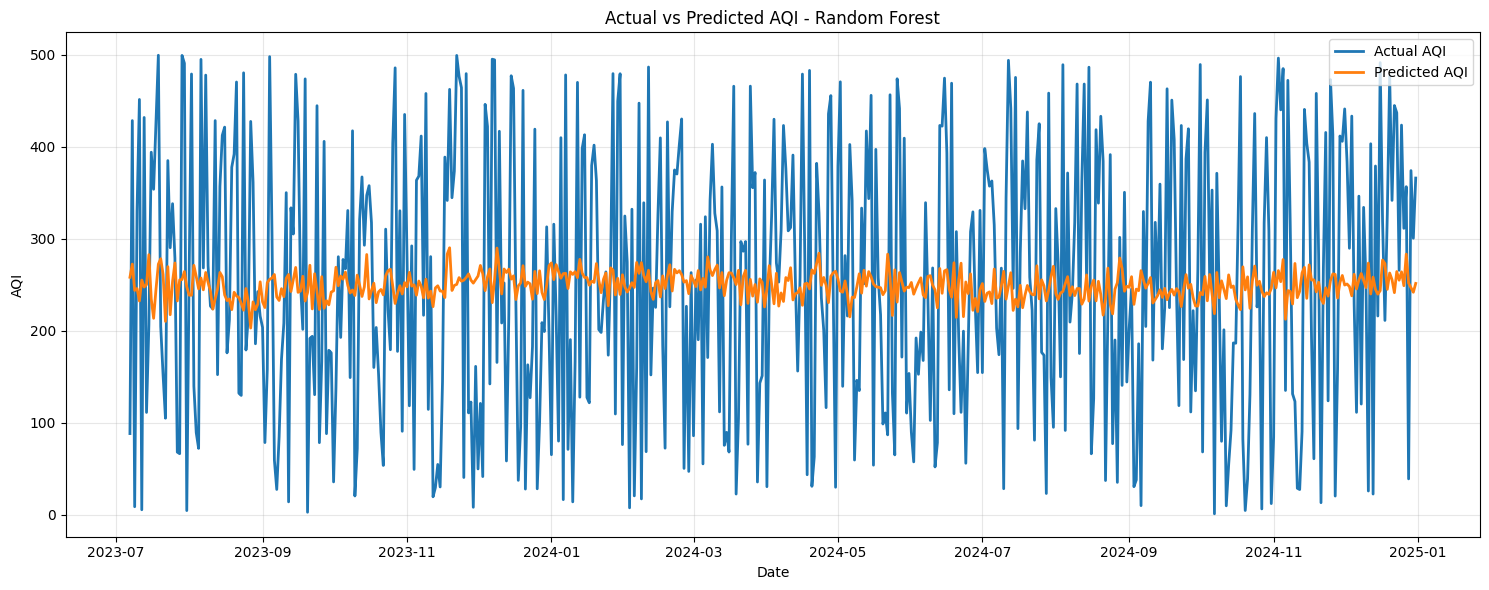

In [25]:
# ============================================================
# ACTUAL VS PREDICTED AQI - RANDOM FOREST
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    test_dates_final,
    y_test_final.values,
    label="Actual AQI",
    linewidth=2
)

plt.plot(
    test_dates_final,
    rf_test_predictions,
    label="Predicted AQI",
    linewidth=2
)

plt.title(
    "Actual vs Predicted AQI - Random Forest"
)

plt.xlabel("Date")
plt.ylabel("AQI")

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

TOP 15 RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
0,AQI_Lag_14,0.0301
1,AQI_Lag_3,0.0293
2,PM10_Lag_7,0.0283
3,PM2.5_Lag_7,0.0283
4,Toluene_Lag_7,0.0279
5,NH3_Lag_1,0.0277
6,AQI_Lag_1,0.0276
7,O3_Lag_1,0.0273
8,AQI_Lag_2,0.0268
9,PM2.5_Lag_1,0.0267


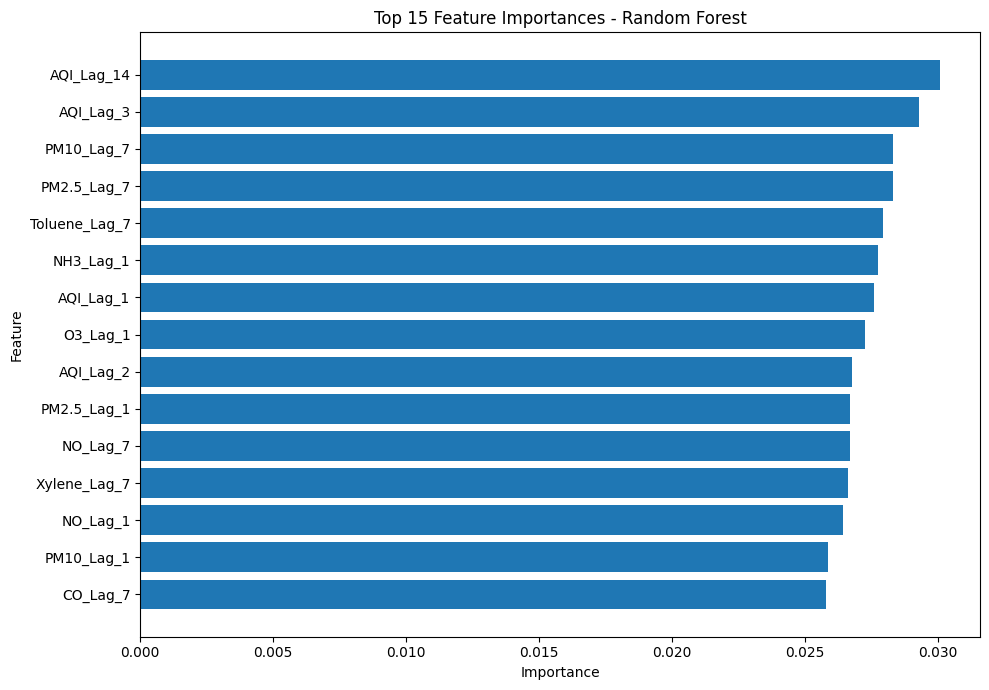

In [26]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": random_forest_model_final.feature_importances_
})

# Sort from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display top 15 features
print("=" * 60)
print("TOP 15 RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

display(
    feature_importance.head(15).round(4)
)

# ============================================================
# VISUALIZE TOP 15 FEATURES
# ============================================================

top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Feature Importances - Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

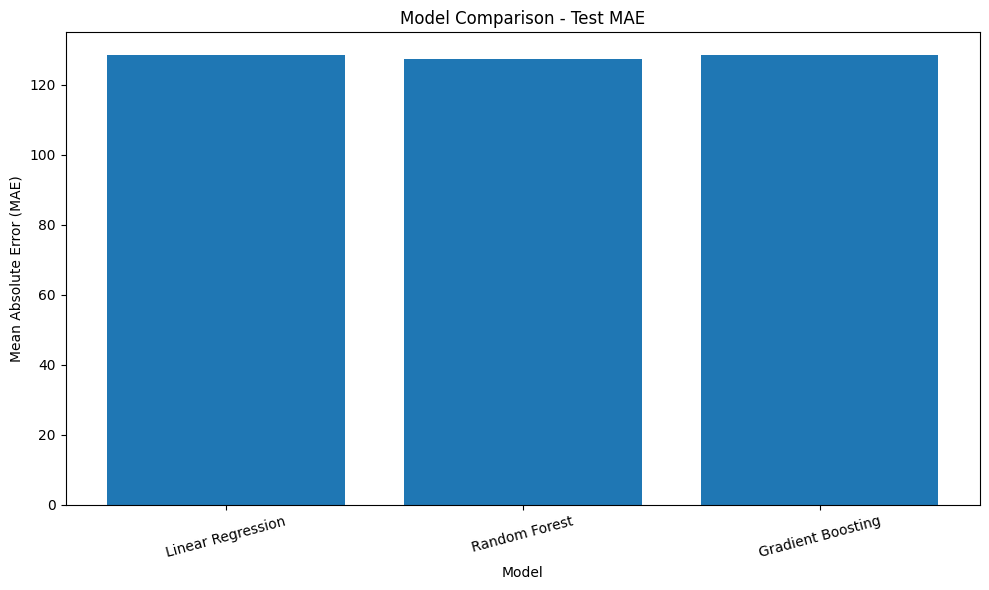

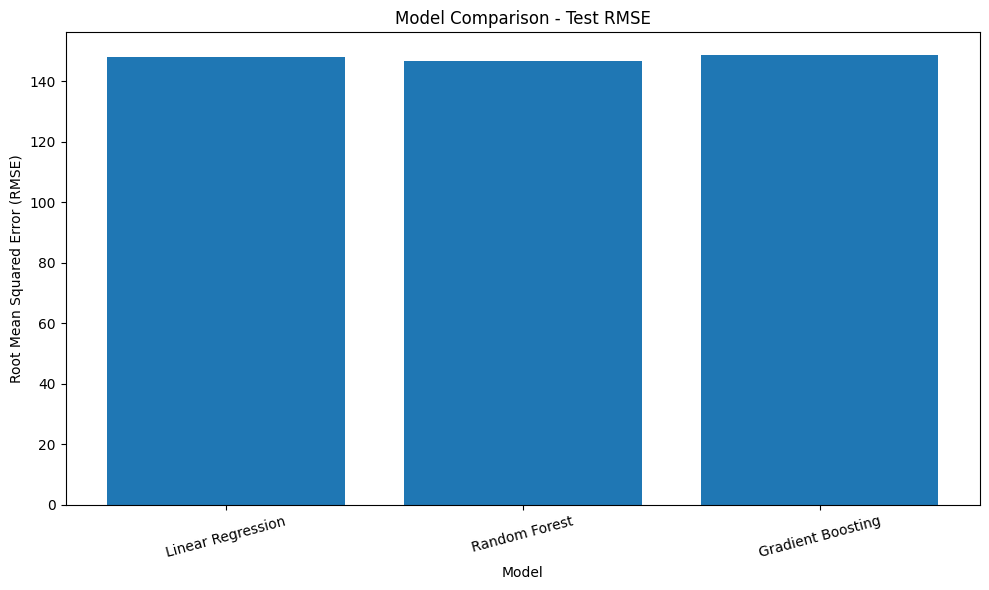

In [27]:
# ============================================================
# FINAL MODEL PERFORMANCE COMPARISON
# ============================================================

import matplotlib.pyplot as plt

models = test_results["Model"]

mae_values = test_results["MAE"]

rmse_values = test_results["RMSE"]

# ------------------------------------------------------------
# MAE comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    models,
    mae_values
)

plt.title(
    "Model Comparison - Test MAE"
)

plt.xlabel("Model")

plt.ylabel("Mean Absolute Error (MAE)")

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# RMSE comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    models,
    rmse_values
)

plt.title(
    "Model Comparison - Test RMSE"
)

plt.xlabel("Model")

plt.ylabel("Root Mean Squared Error (RMSE)")

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

In [28]:
# ============================================================
# 30-DAY FUTURE AQI FORECASTING MODEL
# ============================================================
# This model uses only historical AQI and calendar information.
# No future pollutant measurements are required.
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

# ------------------------------------------------------------
# Select AQI-only forecasting features
# ------------------------------------------------------------

future_features = [
    "AQI_Lag_1",
    "AQI_Lag_2",
    "AQI_Lag_3",
    "AQI_Lag_7",
    "AQI_Lag_14",
    "AQI_Lag_30",
    "AQI_Rolling_Mean_7",
    "AQI_Rolling_Mean_14",
    "AQI_Rolling_Mean_30",
    "AQI_Rolling_Std_7",
    "Month",
    "Day",
    "DayOfWeek",
    "Quarter",
    "DayOfYear",
    "IsWeekend",
    "Month_Sin",
    "Month_Cos",
    "DayOfYear_Sin",
    "DayOfYear_Cos"
]

# ------------------------------------------------------------
# Create training dataset
# ------------------------------------------------------------

future_model_data = chennai_final[
    [
        "Datetime",
        "AQI"
    ]
].copy()

# ------------------------------------------------------------
# Create AQI-only lag features
# ------------------------------------------------------------

future_model_data["AQI_Lag_1"] = (
    future_model_data["AQI"].shift(1)
)

future_model_data["AQI_Lag_2"] = (
    future_model_data["AQI"].shift(2)
)

future_model_data["AQI_Lag_3"] = (
    future_model_data["AQI"].shift(3)
)

future_model_data["AQI_Lag_7"] = (
    future_model_data["AQI"].shift(7)
)

future_model_data["AQI_Lag_14"] = (
    future_model_data["AQI"].shift(14)
)

future_model_data["AQI_Lag_30"] = (
    future_model_data["AQI"].shift(30)
)

# ------------------------------------------------------------
# Rolling AQI features
# ------------------------------------------------------------

future_model_data["AQI_Rolling_Mean_7"] = (
    future_model_data["AQI"]
    .shift(1)
    .rolling(7)
    .mean()
)

future_model_data["AQI_Rolling_Mean_14"] = (
    future_model_data["AQI"]
    .shift(1)
    .rolling(14)
    .mean()
)

future_model_data["AQI_Rolling_Mean_30"] = (
    future_model_data["AQI"]
    .shift(1)
    .rolling(30)
    .mean()
)

future_model_data["AQI_Rolling_Std_7"] = (
    future_model_data["AQI"]
    .shift(1)
    .rolling(7)
    .std()
)

# ------------------------------------------------------------
# Calendar features
# ------------------------------------------------------------

future_model_data["Month"] = (
    future_model_data["Datetime"].dt.month
)

future_model_data["Day"] = (
    future_model_data["Datetime"].dt.day
)

future_model_data["DayOfWeek"] = (
    future_model_data["Datetime"].dt.dayofweek
)

future_model_data["Quarter"] = (
    future_model_data["Datetime"].dt.quarter
)

future_model_data["DayOfYear"] = (
    future_model_data["Datetime"].dt.dayofyear
)

future_model_data["IsWeekend"] = (
    future_model_data["DayOfWeek"] >= 5
).astype(int)

# ------------------------------------------------------------
# Cyclical features
# ------------------------------------------------------------

future_model_data["Month_Sin"] = np.sin(
    2 * np.pi * future_model_data["Month"] / 12
)

future_model_data["Month_Cos"] = np.cos(
    2 * np.pi * future_model_data["Month"] / 12
)

future_model_data["DayOfYear_Sin"] = np.sin(
    2 * np.pi *
    future_model_data["DayOfYear"] / 365.25
)

future_model_data["DayOfYear_Cos"] = np.cos(
    2 * np.pi *
    future_model_data["DayOfYear"] / 365.25
)

# ------------------------------------------------------------
# Remove rows with missing values
# ------------------------------------------------------------

future_model_data = future_model_data.dropna().copy()

# ------------------------------------------------------------
# Prepare X and y
# ------------------------------------------------------------

X_future_train = future_model_data[
    future_features
]

y_future_train = future_model_data[
    "AQI"
]

# ------------------------------------------------------------
# Train forecasting Random Forest
# ------------------------------------------------------------

future_rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

future_rf_model.fit(
    X_future_train,
    y_future_train
)

# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("=" * 60)
print("FUTURE AQI FORECASTING MODEL READY")
print("=" * 60)

print(
    "\nTraining records:",
    len(X_future_train)
)

print(
    "Number of features:",
    len(future_features)
)

print("\nFeatures used:")
print(future_features)

print(
    "\nLast historical date:",
    future_model_data["Datetime"].max().date()
)

print(
    "\nLast known AQI:",
    round(
        future_model_data["AQI"].iloc[-1],
        2
    )
)

print(
    "\nModel: Random Forest"
)

print(
    "\nForecast horizon: 30 days"
)

FUTURE AQI FORECASTING MODEL READY

Training records: 3623
Number of features: 20

Features used:
['AQI_Lag_1', 'AQI_Lag_2', 'AQI_Lag_3', 'AQI_Lag_7', 'AQI_Lag_14', 'AQI_Lag_30', 'AQI_Rolling_Mean_7', 'AQI_Rolling_Mean_14', 'AQI_Rolling_Mean_30', 'AQI_Rolling_Std_7', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'DayOfYear', 'IsWeekend', 'Month_Sin', 'Month_Cos', 'DayOfYear_Sin', 'DayOfYear_Cos']

Last historical date: 2024-12-31

Last known AQI: 366.1

Model: Random Forest

Forecast horizon: 30 days


In [29]:
# ============================================================
# GENERATE 30-DAY FUTURE AQI FORECAST
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Historical AQI values
# ------------------------------------------------------------

historical_aqi = (
    future_model_data["AQI"]
    .tolist()
)

last_date = future_model_data["Datetime"].max()

# Store future predictions
future_predictions = []

future_dates = []

# ------------------------------------------------------------
# Generate predictions one day at a time
# ------------------------------------------------------------

for day in range(1, 31):

    # Future date
    future_date = (
        last_date + pd.Timedelta(days=day)
    )

    # --------------------------------------------------------
    # Historical AQI lag features
    # --------------------------------------------------------

    lag_1 = historical_aqi[-1]

    lag_2 = historical_aqi[-2]

    lag_3 = historical_aqi[-3]

    lag_7 = historical_aqi[-7]

    lag_14 = historical_aqi[-14]

    lag_30 = historical_aqi[-30]

    # --------------------------------------------------------
    # Rolling features
    # --------------------------------------------------------

    rolling_mean_7 = np.mean(
        historical_aqi[-7:]
    )

    rolling_mean_14 = np.mean(
        historical_aqi[-14:]
    )

    rolling_mean_30 = np.mean(
        historical_aqi[-30:]
    )

    rolling_std_7 = np.std(
        historical_aqi[-7:],
        ddof=1
    )

    # --------------------------------------------------------
    # Calendar features
    # --------------------------------------------------------

    month = future_date.month

    day_of_month = future_date.day

    day_of_week = future_date.dayofweek

    quarter = future_date.quarter

    day_of_year = future_date.dayofyear

    is_weekend = int(
        day_of_week >= 5
    )

    # --------------------------------------------------------
    # Cyclical features
    # --------------------------------------------------------

    month_sin = np.sin(
        2 * np.pi * month / 12
    )

    month_cos = np.cos(
        2 * np.pi * month / 12
    )

    day_of_year_sin = np.sin(
        2 * np.pi *
        day_of_year / 365.25
    )

    day_of_year_cos = np.cos(
        2 * np.pi *
        day_of_year / 365.25
    )

    # --------------------------------------------------------
    # Create one-row feature dataframe
    # --------------------------------------------------------

    future_input = pd.DataFrame([{

        "AQI_Lag_1": lag_1,

        "AQI_Lag_2": lag_2,

        "AQI_Lag_3": lag_3,

        "AQI_Lag_7": lag_7,

        "AQI_Lag_14": lag_14,

        "AQI_Lag_30": lag_30,

        "AQI_Rolling_Mean_7": rolling_mean_7,

        "AQI_Rolling_Mean_14": rolling_mean_14,

        "AQI_Rolling_Mean_30": rolling_mean_30,

        "AQI_Rolling_Std_7": rolling_std_7,

        "Month": month,

        "Day": day_of_month,

        "DayOfWeek": day_of_week,

        "Quarter": quarter,

        "DayOfYear": day_of_year,

        "IsWeekend": is_weekend,

        "Month_Sin": month_sin,

        "Month_Cos": month_cos,

        "DayOfYear_Sin": day_of_year_sin,

        "DayOfYear_Cos": day_of_year_cos

    }])

    # --------------------------------------------------------
    # Predict AQI
    # --------------------------------------------------------

    predicted_aqi = future_rf_model.predict(
        future_input
    )[0]

    # Keep prediction within valid AQI range
    predicted_aqi = np.clip(
        predicted_aqi,
        0,
        500
    )

    # Save prediction
    future_predictions.append(
        predicted_aqi
    )

    future_dates.append(
        future_date
    )

    # --------------------------------------------------------
    # Add prediction to history
    # --------------------------------------------------------
    # This allows the next day's prediction
    # to use the previous predicted AQI.

    historical_aqi.append(
        predicted_aqi
    )

# ============================================================
# CREATE FORECAST TABLE
# ============================================================

future_forecast = pd.DataFrame({

    "Date": future_dates,

    "Predicted_AQI": future_predictions

})

# Round predictions
future_forecast["Predicted_AQI"] = (
    future_forecast["Predicted_AQI"].round(2)
)

# ============================================================
# DISPLAY FORECAST
# ============================================================

print("=" * 60)
print("30-DAY FUTURE AQI FORECAST")
print("=" * 60)

print(
    "\nForecast period:"
)

print(
    future_forecast["Date"].min().date(),
    "to",
    future_forecast["Date"].max().date()
)

print(
    "\nNumber of forecast days:",
    len(future_forecast)
)

print("\nPredicted AQI:")

display(
    future_forecast
)

# ============================================================
# FORECAST SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FORECAST SUMMARY")
print("=" * 60)

print(
    "\nAverage predicted AQI:",
    round(
        future_forecast["Predicted_AQI"].mean(),
        2
    )
)

print(
    "Minimum predicted AQI:",
    round(
        future_forecast["Predicted_AQI"].min(),
        2
    )
)

print(
    "Maximum predicted AQI:",
    round(
        future_forecast["Predicted_AQI"].max(),
        2
    )
)

30-DAY FUTURE AQI FORECAST

Forecast period:
2025-01-01 to 2025-01-30

Number of forecast days: 30

Predicted AQI:


,Date,Predicted_AQI
0,2025-01-01,244.02
1,2025-01-02,251.31
2,2025-01-03,235.06
3,2025-01-04,249.55
4,2025-01-05,241.48
5,2025-01-06,238.83
6,2025-01-07,248.26
7,2025-01-08,246.44
8,2025-01-09,249.52
9,2025-01-10,259.47



FORECAST SUMMARY

Average predicted AQI: 247.42
Minimum predicted AQI: 220.8
Maximum predicted AQI: 272.81


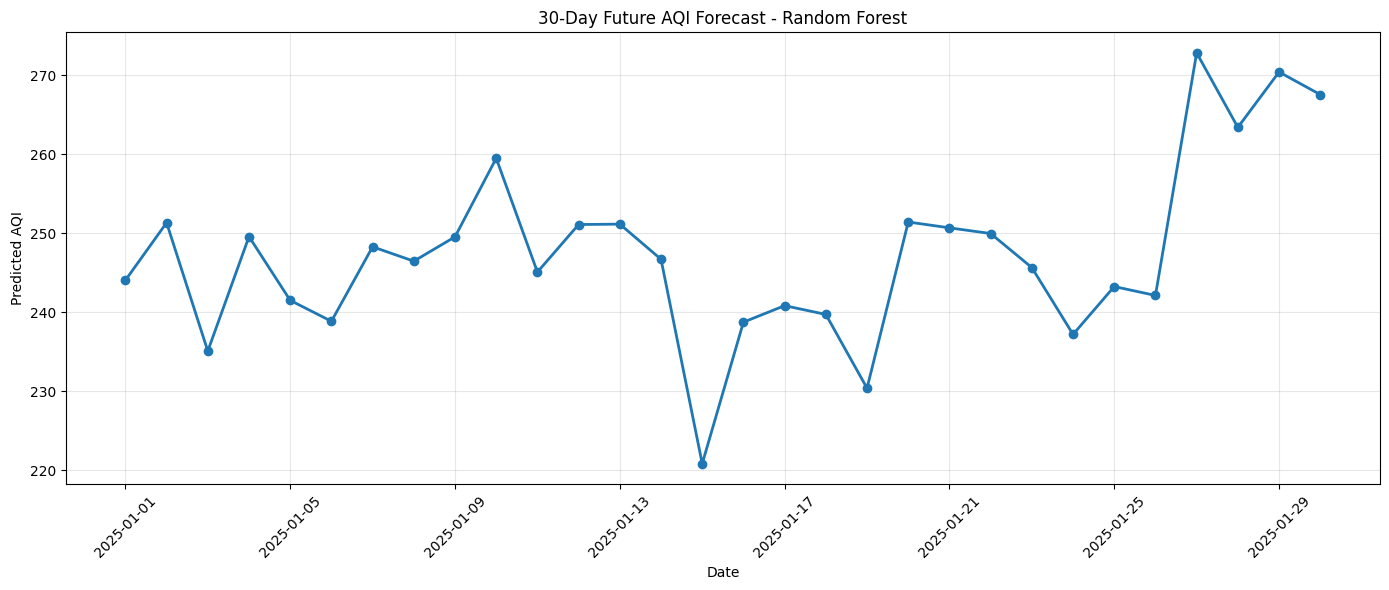

In [30]:
# ============================================================
# 30-DAY FUTURE AQI FORECAST VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    future_forecast["Date"],
    future_forecast["Predicted_AQI"],
    marker="o",
    linewidth=2
)

plt.title(
    "30-Day Future AQI Forecast - Random Forest"
)

plt.xlabel("Date")

plt.ylabel("Predicted AQI")

plt.xticks(
    rotation=45
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [31]:
# ============================================================
# AQI CATEGORY CLASSIFICATION FOR 30-DAY FORECAST
# ============================================================

def classify_aqi(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Satisfactory"

    elif aqi <= 200:
        return "Moderate"

    elif aqi <= 300:
        return "Poor"

    elif aqi <= 400:
        return "Very Poor"

    else:
        return "Severe"


# Apply AQI category
future_forecast["AQI_Category"] = (
    future_forecast["Predicted_AQI"]
    .apply(classify_aqi)
)

# ============================================================
# DISPLAY FORECAST WITH CATEGORY
# ============================================================

print("=" * 60)
print("30-DAY AQI FORECAST WITH CATEGORY")
print("=" * 60)

display(
    future_forecast
)

# ============================================================
# CATEGORY SUMMARY
# ============================================================

category_counts = (
    future_forecast["AQI_Category"]
    .value_counts()
    .reindex(
        [
            "Good",
            "Satisfactory",
            "Moderate",
            "Poor",
            "Very Poor",
            "Severe"
        ],
        fill_value=0
    )
)

print("\n" + "=" * 60)
print("AQI CATEGORY SUMMARY")
print("=" * 60)

for category, count in category_counts.items():

    print(
        f"{category}: {count} days"
    )

# ============================================================
# DOMINANT CATEGORY
# ============================================================

dominant_category = category_counts.idxmax()

dominant_days = category_counts.max()

print("\n" + "=" * 60)
print("FORECAST INTERPRETATION")
print("=" * 60)

print(
    f"\nDominant AQI category: {dominant_category}"
)

print(
    f"Number of days in this category: {dominant_days}"
)

print(
    "\nAverage predicted AQI:",
    round(
        future_forecast["Predicted_AQI"].mean(),
        2
    )
)

print(
    "Minimum predicted AQI:",
    round(
        future_forecast["Predicted_AQI"].min(),
        2
    )
)

print(
    "Maximum predicted AQI:",
    round(
        future_forecast["Predicted_AQI"].max(),
        2
    )
)

30-DAY AQI FORECAST WITH CATEGORY


,Date,Predicted_AQI,AQI_Category
0,2025-01-01,244.02,Poor
1,2025-01-02,251.31,Poor
2,2025-01-03,235.06,Poor
3,2025-01-04,249.55,Poor
4,2025-01-05,241.48,Poor
5,2025-01-06,238.83,Poor
6,2025-01-07,248.26,Poor
7,2025-01-08,246.44,Poor
8,2025-01-09,249.52,Poor
9,2025-01-10,259.47,Poor



AQI CATEGORY SUMMARY
Good: 0 days
Satisfactory: 0 days
Moderate: 0 days
Poor: 30 days
Very Poor: 0 days
Severe: 0 days

FORECAST INTERPRETATION

Dominant AQI category: Poor
Number of days in this category: 30

Average predicted AQI: 247.42
Minimum predicted AQI: 220.8
Maximum predicted AQI: 272.81


In [32]:
# ============================================================
# EXPORT FINAL PROJECT RESULTS
# ============================================================

# ------------------------------------------------------------
# 1. Export 30-day AQI forecast
# ------------------------------------------------------------

future_forecast.to_csv(
    "chennai_aqi_30_day_forecast.csv",
    index=False
)

# ------------------------------------------------------------
# 2. Export model test results
# ------------------------------------------------------------

test_results.to_csv(
    "model_test_results.csv",
    index=False
)

# ------------------------------------------------------------
# 3. Export feature importance
# ------------------------------------------------------------

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

# ============================================================
# CONFIRM FILES
# ============================================================

print("=" * 60)
print("PROJECT RESULTS EXPORTED SUCCESSFULLY")
print("=" * 60)

print("\nCreated files:")

print("1. chennai_aqi_30_day_forecast.csv")
print("2. model_test_results.csv")
print("3. feature_importance.csv")

print("\nForecast records exported:", len(future_forecast))

print(
    "Model results exported:",
    len(test_results)
)

print(
    "Feature importance records exported:",
    len(feature_importance)
)

PROJECT RESULTS EXPORTED SUCCESSFULLY

Created files:
1. chennai_aqi_30_day_forecast.csv
2. model_test_results.csv
3. feature_importance.csv

Forecast records exported: 30
Model results exported: 3
Feature importance records exported: 44


In [33]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("AIR QUALITY INDEX (AQI) PREDICTION - FINAL PROJECT SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# PROJECT INFORMATION
# ------------------------------------------------------------

print("\nPROJECT INFORMATION")
print("-" * 50)

print("Dataset              : Air Quality Data in India")
print("City                 : Chennai")
print("Historical Period    : 2015-2024")
print("Target Variable      : AQI")
print("Forecast Frequency   : Daily")
print("Forecast Horizon     : 30 Days")

# ------------------------------------------------------------
# DATASET INFORMATION
# ------------------------------------------------------------

print("\nDATASET INFORMATION")
print("-" * 50)

print("Original Chennai Records :", len(chennai_final))
print("Modeling Records         :", len(final_modeling_data))
print("Prediction Features      :", len(final_feature_columns))

print("\nTrain Records            :", len(X_train_final))
print("Validation Records       :", len(X_val_final))
print("Test Records             :", len(X_test_final))

# ------------------------------------------------------------
# TEST PERFORMANCE
# ------------------------------------------------------------

print("\nFINAL TEST PERFORMANCE")
print("-" * 50)

for _, row in test_results.iterrows():

    print(
        f"{row['Model']:<20} "
        f"MAE: {row['MAE']:<8} "
        f"RMSE: {row['RMSE']:<8} "
        f"R²: {row['R2 Score']}"
    )

# ------------------------------------------------------------
# BEST MODEL
# ------------------------------------------------------------

print("\nSELECTED MODEL")
print("-" * 50)

print("Model: Random Forest")

print(
    f"Test MAE  : {rf_test_mae:.2f}"
)

print(
    f"Test RMSE : {rf_test_rmse:.2f}"
)

print(
    f"Test R²   : {rf_test_r2:.4f}"
)

# ------------------------------------------------------------
# FUTURE FORECAST
# ------------------------------------------------------------

print("\n30-DAY FUTURE AQI FORECAST")
print("-" * 50)

print(
    "Forecast Start :",
    future_forecast["Date"].min().date()
)

print(
    "Forecast End   :",
    future_forecast["Date"].max().date()
)

print(
    "Average AQI    :",
    round(
        future_forecast["Predicted_AQI"].mean(),
        2
    )
)

print(
    "Minimum AQI    :",
    round(
        future_forecast["Predicted_AQI"].min(),
        2
    )
)

print(
    "Maximum AQI    :",
    round(
        future_forecast["Predicted_AQI"].max(),
        2
    )
)

# ------------------------------------------------------------
# AQI CATEGORY SUMMARY
# ------------------------------------------------------------

print("\nAQI CATEGORY SUMMARY")
print("-" * 50)

for category, count in category_counts.items():

    if count > 0:
        print(
            f"{category:<15}: {count} days"
        )

# ------------------------------------------------------------
# TOP FEATURES
# ------------------------------------------------------------

print("\nTOP 10 IMPORTANT FEATURES")
print("-" * 50)

for i, row in feature_importance.head(10).iterrows():

    print(
        f"{i + 1}. "
        f"{row['Feature']:<25} "
        f"{row['Importance']:.4f}"
    )

# ------------------------------------------------------------
# FINAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL CONCLUSION")
print("=" * 70)

print(
    "\nRandom Forest was selected as the final model because "
    "it achieved the best performance on the unseen test dataset "
    "across MAE, RMSE and R²."
)

print(
    "\nThe 30-day recursive forecast predicts AQI values between "
    f"{future_forecast['Predicted_AQI'].min():.2f} and "
    f"{future_forecast['Predicted_AQI'].max():.2f}, "
    f"with an average of "
    f"{future_forecast['Predicted_AQI'].mean():.2f}."
)

print(
    "\nAll 30 forecasted days are classified as Poor AQI."
)

print(
    "\nNote: The test R² is close to zero, indicating that "
    "the model has limited ability to explain day-to-day AQI "
    "variation. Results should therefore be interpreted as "
    "a baseline forecasting system rather than a highly accurate "
    "AQI prediction system."
)

print("\n" + "=" * 70)
print("PROJECT COMPLETE")
print("=" * 70)

AIR QUALITY INDEX (AQI) PREDICTION - FINAL PROJECT SUMMARY

PROJECT INFORMATION
--------------------------------------------------
Dataset              : Air Quality Data in India
City                 : Chennai
Historical Period    : 2015-2024
Target Variable      : AQI
Forecast Frequency   : Daily
Forecast Horizon     : 30 Days

DATASET INFORMATION
--------------------------------------------------
Original Chennai Records : 3653
Modeling Records         : 3623
Prediction Features      : 44

Train Records            : 2536
Validation Records       : 543
Test Records             : 544

FINAL TEST PERFORMANCE
--------------------------------------------------
Linear Regression    MAE: 128.49   RMSE: 147.96   R²: -0.0269
Random Forest        MAE: 127.45   RMSE: 146.68   R²: -0.0093
Gradient Boosting    MAE: 128.52   RMSE: 148.72   R²: -0.0375

SELECTED MODEL
--------------------------------------------------
Model: Random Forest
Test MAE  : 127.45
Test RMSE : 146.68
Test R²   : -0.0093



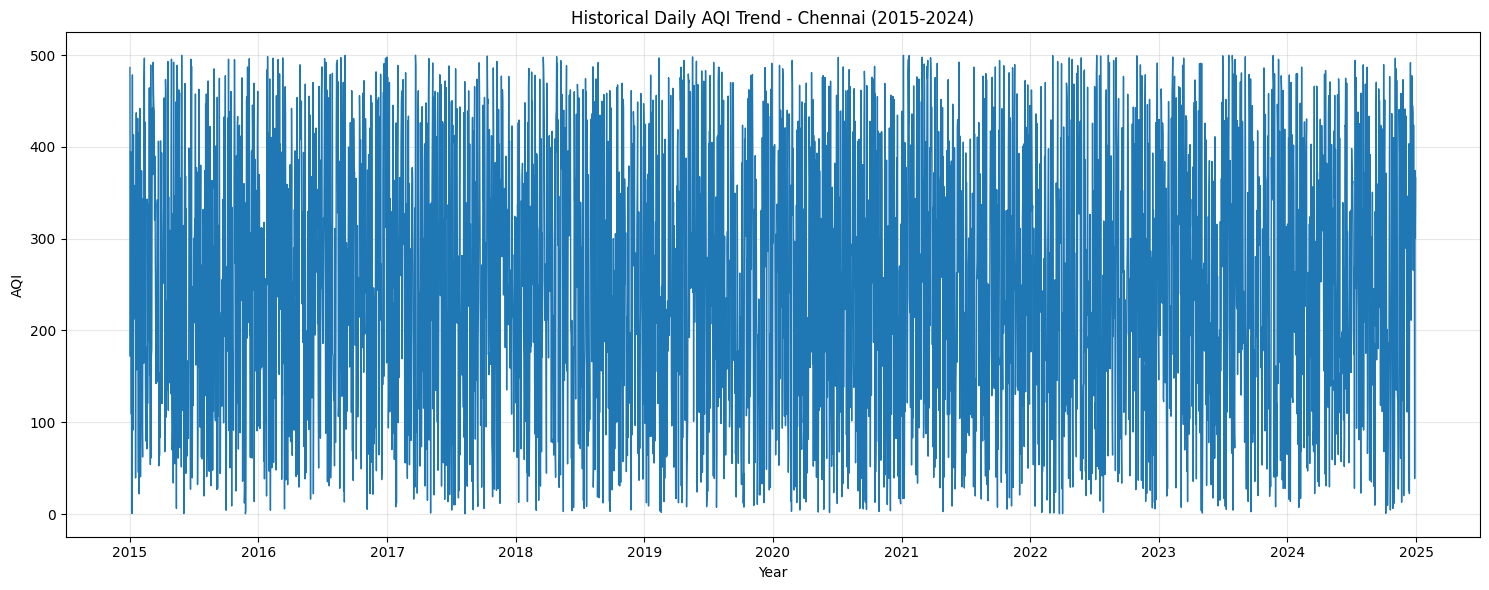

HISTORICAL AQI ANALYSIS

Period: 2015-01-01 to 2024-12-31
Number of AQI observations: 3653
Average AQI: 250.34
Minimum AQI: 0.3
Maximum AQI: 499.8


In [34]:
# ============================================================
# HISTORICAL AQI TREND ANALYSIS - CHENNAI
# ============================================================

import matplotlib.pyplot as plt

# Use the original Chennai AQI data
historical_aqi = chennai_final[
    ["Datetime", "AQI"]
].dropna().copy()

# Sort by date
historical_aqi = historical_aqi.sort_values(
    "Datetime"
)

# ============================================================
# PLOT HISTORICAL AQI
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    historical_aqi["Datetime"],
    historical_aqi["AQI"],
    linewidth=1
)

plt.title(
    "Historical Daily AQI Trend - Chennai (2015-2024)"
)

plt.xlabel("Year")

plt.ylabel("AQI")

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ============================================================
# HISTORICAL AQI SUMMARY
# ============================================================

print("=" * 60)
print("HISTORICAL AQI ANALYSIS")
print("=" * 60)

print(
    "\nPeriod:",
    historical_aqi["Datetime"].min().date(),
    "to",
    historical_aqi["Datetime"].max().date()
)

print(
    "Number of AQI observations:",
    len(historical_aqi)
)

print(
    "Average AQI:",
    round(historical_aqi["AQI"].mean(), 2)
)

print(
    "Minimum AQI:",
    round(historical_aqi["AQI"].min(), 2)
)

print(
    "Maximum AQI:",
    round(historical_aqi["AQI"].max(), 2)
)

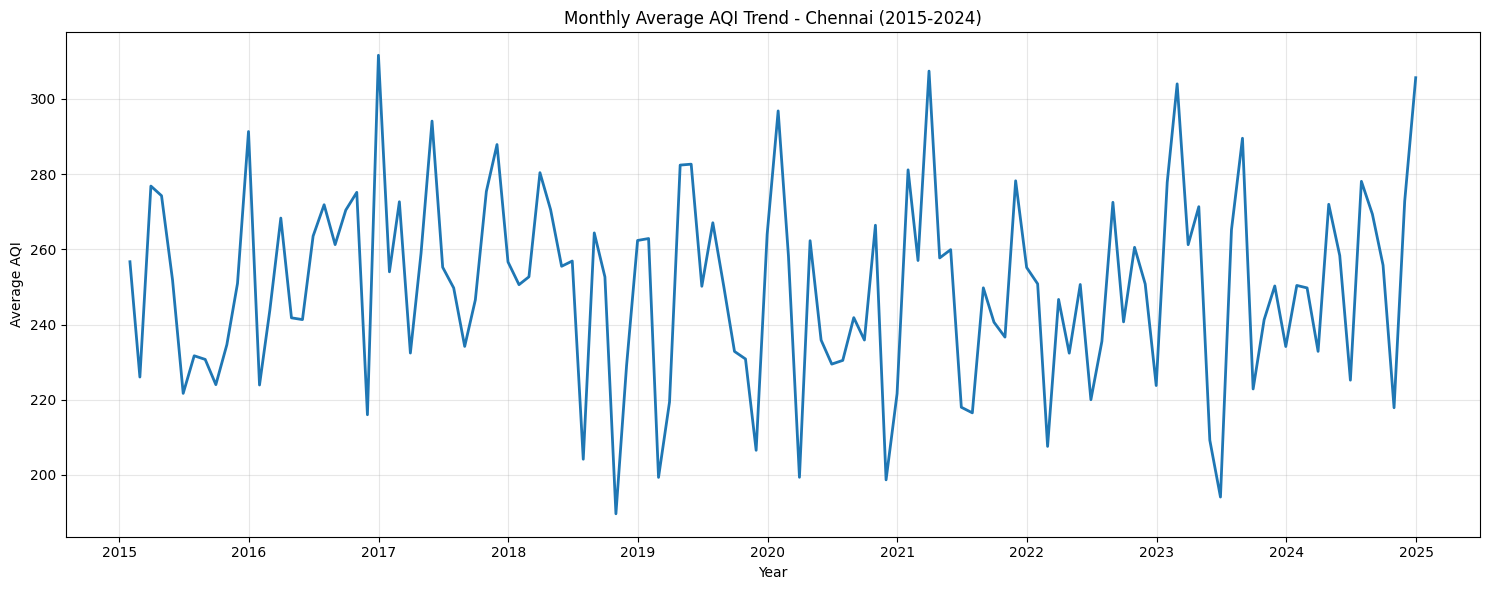

MONTHLY AQI TREND ANALYSIS

Number of months analyzed: 120
Overall monthly average AQI: 250.26
Highest monthly average AQI: 311.61
Lowest monthly average AQI: 189.68

Highest AQI month: December 2016
Lowest AQI month: October 2018


In [35]:
# ============================================================
# MONTHLY AVERAGE AQI TREND - CHENNAI
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Create a copy of historical AQI data
monthly_aqi = historical_aqi.copy()

# Set date as index
monthly_aqi = monthly_aqi.set_index(
    "Datetime"
)

# Calculate monthly average AQI
monthly_average = (
    monthly_aqi["AQI"]
    .resample("ME")
    .mean()
)

# ============================================================
# PLOT MONTHLY AQI TREND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    linewidth=2
)

plt.title(
    "Monthly Average AQI Trend - Chennai (2015-2024)"
)

plt.xlabel("Year")

plt.ylabel("Average AQI")

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ============================================================
# MONTHLY AQI SUMMARY
# ============================================================

print("=" * 60)
print("MONTHLY AQI TREND ANALYSIS")
print("=" * 60)

print(
    "\nNumber of months analyzed:",
    len(monthly_average)
)

print(
    "Overall monthly average AQI:",
    round(monthly_average.mean(), 2)
)

print(
    "Highest monthly average AQI:",
    round(monthly_average.max(), 2)
)

print(
    "Lowest monthly average AQI:",
    round(monthly_average.min(), 2)
)

# Month with highest average AQI
highest_month = monthly_average.idxmax()

# Month with lowest average AQI
lowest_month = monthly_average.idxmin()

print(
    "\nHighest AQI month:",
    highest_month.strftime("%B %Y")
)

print(
    "Lowest AQI month:",
    lowest_month.strftime("%B %Y")
)

HISTORICAL AQI CATEGORY DISTRIBUTION
Good           :  365 days (9.99%)
Satisfactory   :  361 days (9.88%)
Moderate       :  738 days (20.20%)
Poor           :  730 days (19.98%)
Very Poor      :  693 days (18.97%)
Severe         :  766 days (20.97%)

DOMINANT HISTORICAL AQI CATEGORY

Category: Severe
Number of days: 766
Percentage: 20.97 %


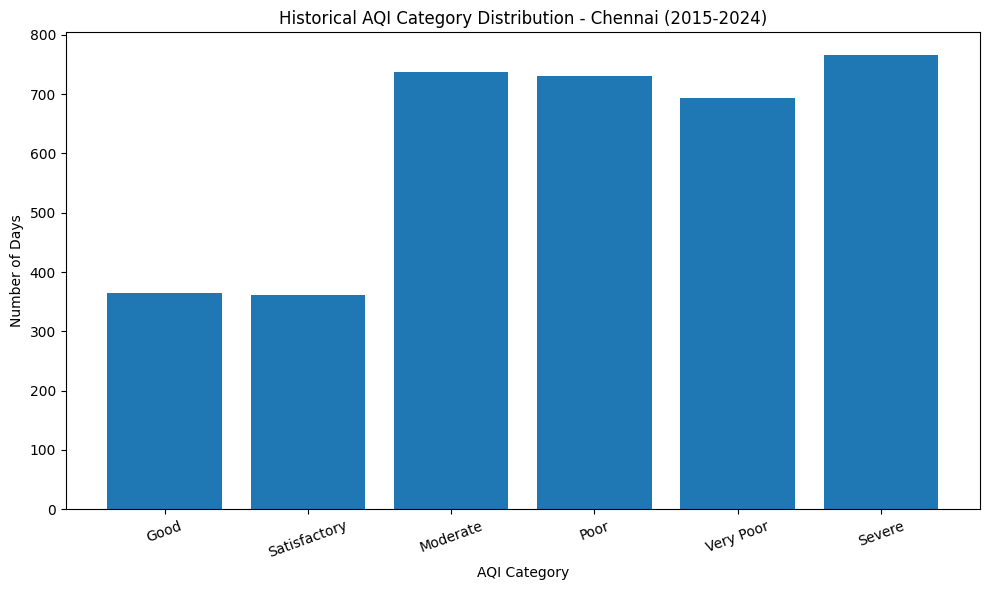

In [36]:
# ============================================================
# HISTORICAL AQI CATEGORY DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# AQI category classification
# ------------------------------------------------------------

historical_aqi["AQI_Category"] = (
    historical_aqi["AQI"].apply(classify_aqi)
)

# ------------------------------------------------------------
# Count each AQI category
# ------------------------------------------------------------

category_order = [
    "Good",
    "Satisfactory",
    "Moderate",
    "Poor",
    "Very Poor",
    "Severe"
]

historical_category_counts = (
    historical_aqi["AQI_Category"]
    .value_counts()
    .reindex(
        category_order,
        fill_value=0
    )
)

# ------------------------------------------------------------
# Display category counts
# ------------------------------------------------------------

print("=" * 60)
print("HISTORICAL AQI CATEGORY DISTRIBUTION")
print("=" * 60)

for category, count in historical_category_counts.items():

    percentage = (
        count /
        len(historical_aqi)
        * 100
    )

    print(
        f"{category:<15}: "
        f"{count:>4} days "
        f"({percentage:.2f}%)"
    )

# ------------------------------------------------------------
# Identify dominant category
# ------------------------------------------------------------

dominant_historical_category = (
    historical_category_counts.idxmax()
)

dominant_historical_days = (
    historical_category_counts.max()
)

print("\n" + "=" * 60)
print("DOMINANT HISTORICAL AQI CATEGORY")
print("=" * 60)

print(
    "\nCategory:",
    dominant_historical_category
)

print(
    "Number of days:",
    dominant_historical_days
)

print(
    "Percentage:",
    round(
        dominant_historical_days /
        len(historical_aqi) *
        100,
        2
    ),
    "%"
)

# ============================================================
# CATEGORY DISTRIBUTION CHART
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    historical_category_counts.index,
    historical_category_counts.values
)

plt.title(
    "Historical AQI Category Distribution - Chennai (2015-2024)"
)

plt.xlabel("AQI Category")

plt.ylabel("Number of Days")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

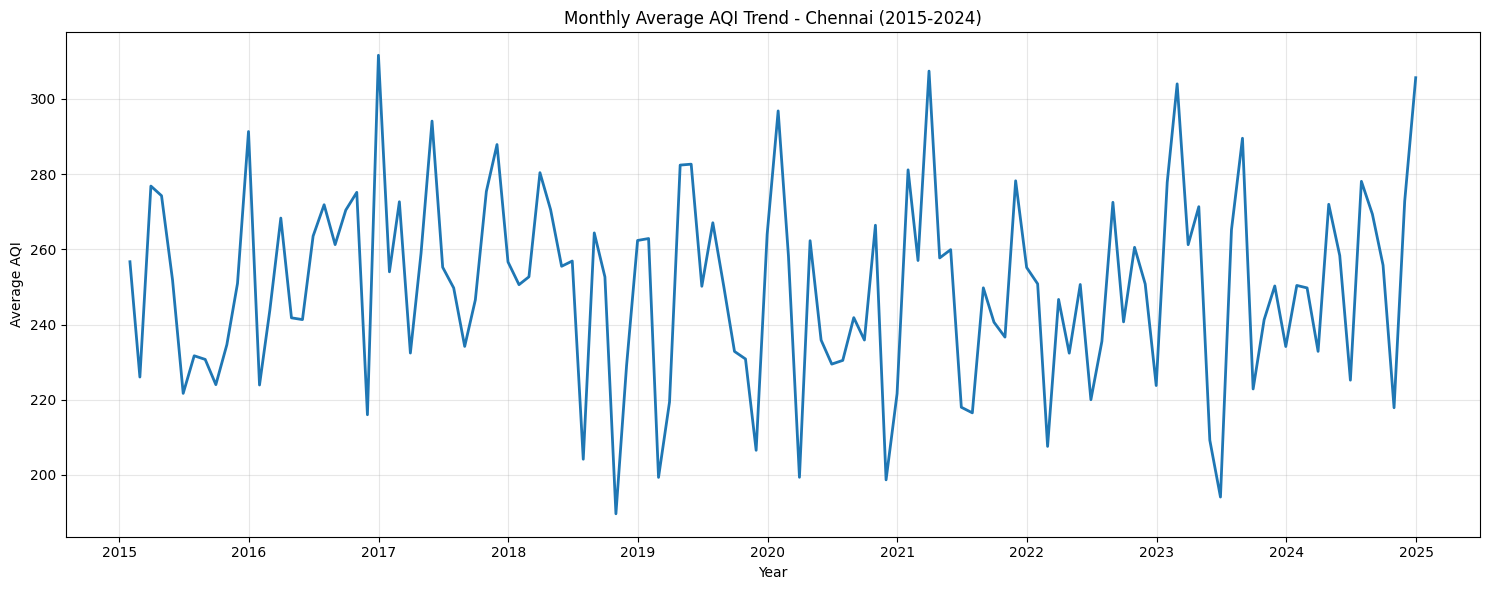

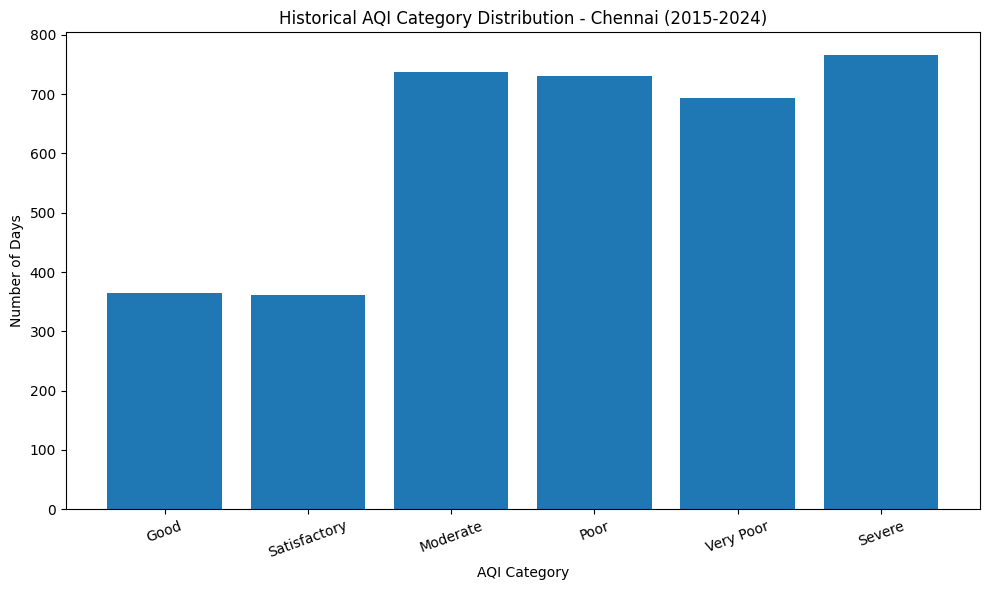

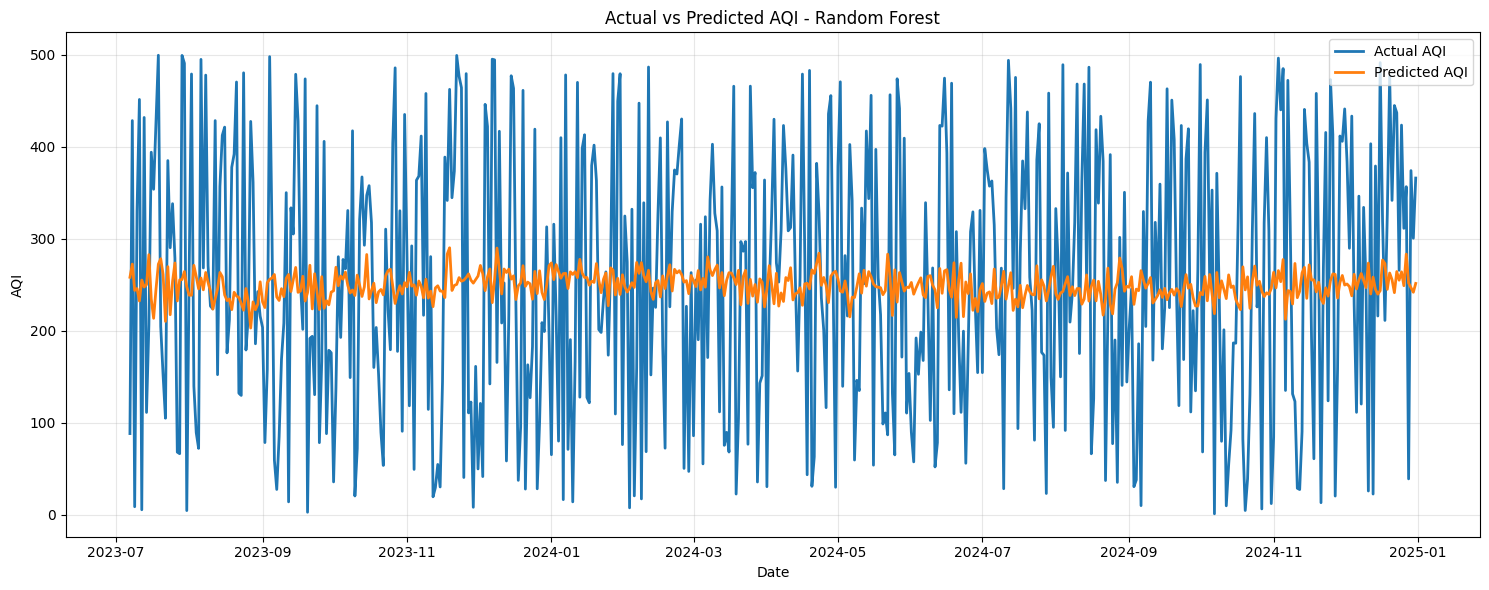

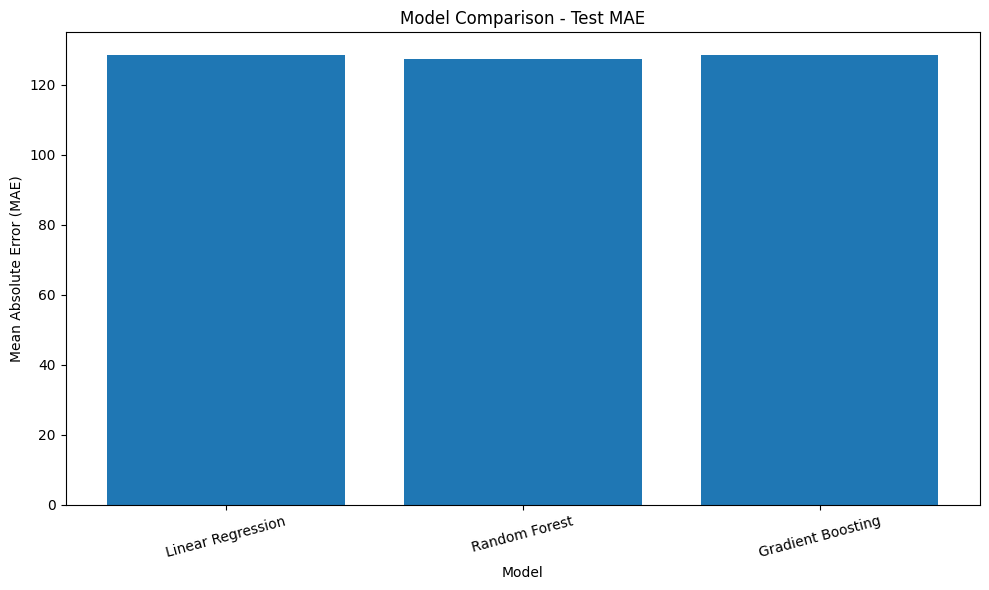

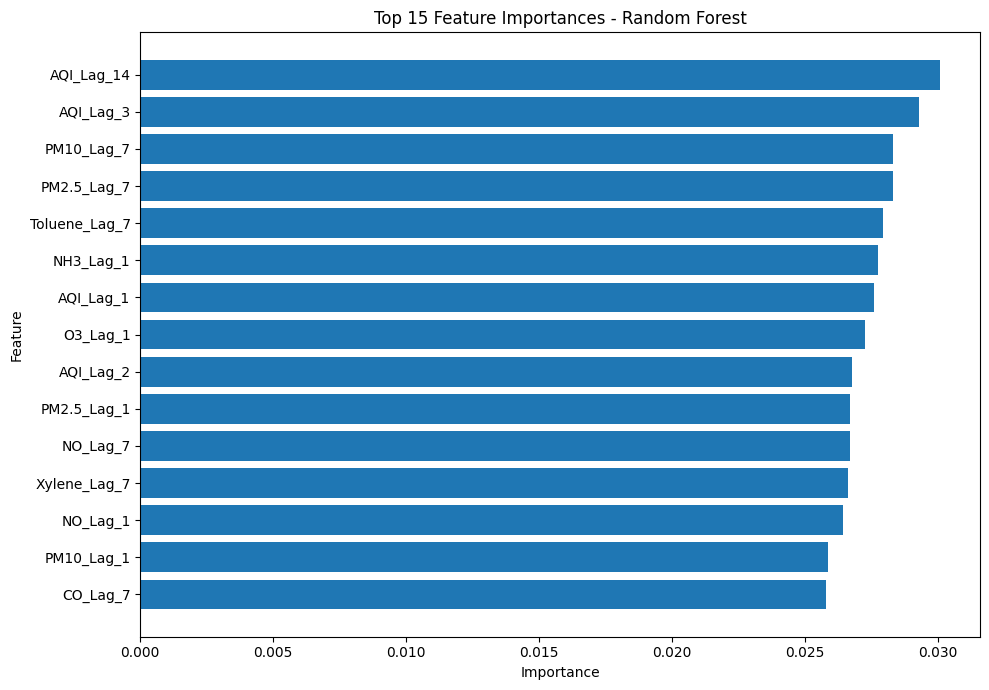

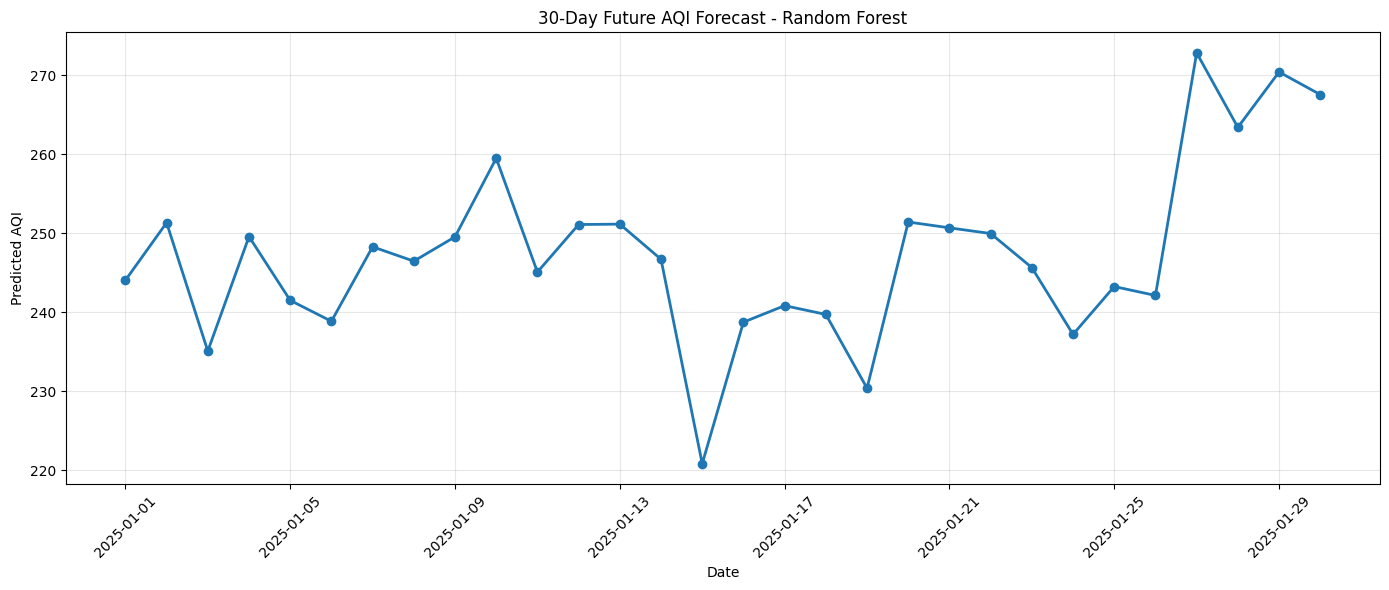

PROJECT VISUALIZATIONS SAVED

Folder: project_visualizations

Files created:
- actual_vs_predicted_aqi.png
- 30_day_aqi_forecast.png
- monthly_aqi_trend.png
- aqi_category_distribution.png
- model_mae_comparison.png
- feature_importance.png

Total visualization files: 6


In [37]:
# ============================================================
# SAVE FINAL PROJECT VISUALIZATIONS
# ============================================================

import os
import matplotlib.pyplot as plt

# Create output folder
output_folder = "project_visualizations"

os.makedirs(
    output_folder,
    exist_ok=True
)

# ============================================================
# 1. MONTHLY AQI TREND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    linewidth=2
)

plt.title(
    "Monthly Average AQI Trend - Chennai (2015-2024)"
)

plt.xlabel("Year")
plt.ylabel("Average AQI")

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_folder,
        "monthly_aqi_trend.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 2. HISTORICAL AQI CATEGORY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    historical_category_counts.index,
    historical_category_counts.values
)

plt.title(
    "Historical AQI Category Distribution - Chennai (2015-2024)"
)

plt.xlabel("AQI Category")
plt.ylabel("Number of Days")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_folder,
        "aqi_category_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 3. ACTUAL VS PREDICTED AQI
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    test_dates_final,
    y_test_final.values,
    label="Actual AQI",
    linewidth=2
)

plt.plot(
    test_dates_final,
    rf_test_predictions,
    label="Predicted AQI",
    linewidth=2
)

plt.title(
    "Actual vs Predicted AQI - Random Forest"
)

plt.xlabel("Date")
plt.ylabel("AQI")

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_folder,
        "actual_vs_predicted_aqi.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 4. MODEL MAE COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    test_results["Model"],
    test_results["MAE"]
)

plt.title(
    "Model Comparison - Test MAE"
)

plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_folder,
        "model_mae_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 5. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

top_features = (
    feature_importance
    .head(15)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Feature Importances - Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_folder,
        "feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 6. 30-DAY FUTURE AQI FORECAST
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    future_forecast["Date"],
    future_forecast["Predicted_AQI"],
    marker="o",
    linewidth=2
)

plt.title(
    "30-Day Future AQI Forecast - Random Forest"
)

plt.xlabel("Date")
plt.ylabel("Predicted AQI")

plt.xticks(
    rotation=45
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_folder,
        "30_day_aqi_forecast.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# CONFIRM FILES
# ============================================================

print("=" * 60)
print("PROJECT VISUALIZATIONS SAVED")
print("=" * 60)

print("\nFolder:", output_folder)

print("\nFiles created:")

for filename in os.listdir(output_folder):

    print("-", filename)

print(
    "\nTotal visualization files:",
    len(os.listdir(output_folder))
)